# Linear Regression 

### __Introduction__

Linear Regression is the simplest supervised learning approach explored in this project and serves as the conceptual starting point for our regression pipeline.
It models the relationship between the predictors and the target variable by fitting a weighted linear combination of the input features. Because of its simplicity and strong theoretical grounding, it provides an interpretable baseline against which more complex models can be compared.

Although car-price data often contains nonlinearities and interactions that linear models cannot capture, this approach remains valuable for several reasons:
- It establishes a benchmark for assessing how much nonlinear models must improve;
- It provides interpretable coefficients, helping us understand directional effects of each feature;
- It highlights structural issues in the data (multicollinearity, skewness, scaling differences) that guide later preprocessing choices;
- It gives us a reference point before introducing regularization (Ridge, Lasso, Elastic Net) and ensemble methods.

This section introduces the foundation of our modeling workflow: how the linear estimator is formulated, how it behaves under real-world data constraints, and how its performance compares to more expressive models we evaluate later in the project.

## 1. Setup and Data Loading

In [1]:
# 1) Imports 
import numpy as np
import pandas as pd

from datetime import datetime

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# 2) Import pre processing helpers
#    -> this should define: full_train_dataset, cat_feat, num_feat,
#       basic_string_transformer, def_string_basic_transformer,
#       preprocess_categorical, MyTargetEncoder, MyOneHotEncoder, etc.
%run 05_0_preproc_helpers.ipynb
%run 05_0.1_visualization_helpers.ipynb  

# 3) Define target
TARGET_COL = "price"

# 4) Separate X and y from the treated dataset
y = full_train_dataset[TARGET_COL].copy()
X = full_train_dataset.drop(columns=[TARGET_COL]).copy()

# Numerical and categorical features (splitted in pre processing)
numeric_features = num_feat
categorical_features = cat_feat

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Num features:", numeric_features)
print("Cat features:", categorical_features)

X shape: (75973, 10)
y shape: (75973,)
Num features: ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']
Cat features: ['Brand', 'model', 'transmission', 'fuelType']


## 2. K-Fold Cross Validation

In [ ]:
valid_transmissions = ["MANUAL", "AUTOMATIC", "SEMIAUTO"]
valid_fueltypes    = ["PETROL", "DIESEL", "HYBRID"]

# KFold configuration
N_SPLITS = 8
RANDOM_STATE = 42

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Containers for overall CV metrics
cv_fold_rmses_train = []
cv_fold_maes_train  = []
cv_fold_r2s_train   = []
cv_fold_bias_train  = []

cv_fold_rmses_val = []
cv_fold_maes_val  = []
cv_fold_r2s_val   = []
cv_fold_bias_val  = []

log_path = "linreg_cv_log.txt"

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        """
        Write a message to a log file with timestamp, keeping track of what's happening while keeping the notebook output clean.
        """
        log_file.write(datetime.now().strftime("[%Y-%m-%d %H:%M:%S] ") + msg + "\n")
        log_file.flush()

    log("# =============================")
    log("# LINEAR REGRESSION - K-FOLD CV")
    log("# =============================")
    log(f"N_SPLITS = {N_SPLITS}")

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        log("")
        log(f"==== FOLD {fold}/{N_SPLITS} ====")

        # 1) SEPARATE TRAIN / VALIDATION
        X_train = X.iloc[train_idx].copy()
        X_val   = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_val   = y.iloc[val_idx].copy()

        log(f"[F{fold}] X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")
        log(f"[F{fold}] y_train shape: {y_train.shape}, y_val shape: {y_val.shape}")

        # NaNs before numeric imputation
        log(f"[F{fold}] NaNs before numeric imputation (num features):")
        log(str(X_train[numeric_features].isna().sum()))

        log(f"[F{fold}] NaNs before (categoricals):")
        log(str(X_train[categorical_features].isna().sum()))

        unknown_counts_before = (X_train[categorical_features] == "UNKNOWN").sum()
        log(f"[F{fold}] 'UNKNOWN' before (categoricals):")
        log(str(unknown_counts_before))

        # 2) NUMERICAL PRE PROCESSING (fit on train, transform train/val)
        year_state = fit_year_median(
            X_train,
            year_col="year",
            model_col="model"
        )
        X_train = transform_year_with_model_median(X_train, state=year_state)
        X_val   = transform_year_with_model_median(X_val,   state=year_state)

        mileage_state = fit_mileage_imputer(
            X_train,
            mileage_col="mileage",
            do_abs=True
        )
        X_train = transform_mileage_imputer(X_train, state=mileage_state)
        X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

        engine_state = fit_engine_size_imputer(
            X_train,
            engine_col="engineSize"
        )
        X_train = transform_engine_size_imputer(X_train, state=engine_state)
        X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

        tax_state = fit_tax_imputer(
            X_train,
            tax_col="tax",
            do_abs=True
        )
        X_train = transform_tax_imputer(X_train, state=tax_state)
        X_val   = transform_tax_imputer(X_val,   state=tax_state)

        mpg_state = fit_mpg_imputer(
            X_train,
            mpg_col="mpg",
            do_abs=True
        )
        X_train = transform_mpg_imputer(X_train, state=mpg_state)
        X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

        # Paint quality was dropped
        '''
        paint_state = fit_paint_quality_imputer(
            X_train,
            paint_col="paintQuality%"
        )
        X_train = transform_paint_quality_imputer(X_train, state=paint_state)
        X_val   = transform_paint_quality_imputer(X_val,   state=paint_state)
        '''

        owners_state = fit_previous_owners_imputer(
            X_train,
            owners_col="previousOwners",
            year_col="year",
            mileage_col="mileage"
        )
        X_train = transform_previous_owners_imputer(X_train, state=owners_state)
        X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

        log(f"[F{fold}] After numeric imputation: X_train shape = {X_train.shape}, X_val shape = {X_val.shape}")
        log(f"[F{fold}] NaNs after numeric imputation (num features):")
        log(str(X_train[numeric_features].isna().sum()))

        # 3) CATEGORICAL RESOLVERS (fit on train, transform train/val)
        # Brand
        brand_state = fit_ambiguous_brand_resolver(
            train_df=X_train,
            valid_brands=valid_brands,
            brand_col="Brand",
            model_col="model",
            year_col="year",
        )

        X_train, _, brand_still_invalid_train = transform_ambiguous_brands(
            X_train,
            brand_state,
        )
        X_val, _, brand_still_invalid_val = transform_ambiguous_brands(
            X_val,
            brand_state,
        )

        log(f"[F{fold}] After solving Brand - still invalid (train): {len(brand_still_invalid_train)}")

        # Model
        model_state = fit_invalid_model_resolver(
            train_df=X_train,
            valid_models_by_brand=valid_models_by_brand,
            brand_col="Brand",
            model_col="model",
            year_col="year",
            fuel_col="fuelType",
            mpg_col="mpg",
        )

        X_train, _, model_still_invalid_train = transform_invalid_models(
            X_train,
            model_state,
        )
        X_val, _, model_still_invalid_val = transform_invalid_models(
            X_val,
            model_state,
        )

        log(f"[F{fold}] After solving model - still invalid (train): {len(model_still_invalid_train)}")

        # Transmission
        transm_state = fit_transmission_resolver(
            train_df=X_train,
            valid_transmissions=valid_transmissions,
            transm_col="transmission",
            brand_col="Brand",
            model_col="model",
            fuel_col="fuelType",
        )

        X_train, _, transm_still_invalid_train = transform_transmission_resolver(
            X_train,
            transm_state,
        )
        X_val, _, transm_still_invalid_val = transform_transmission_resolver(
            X_val,
            transm_state,
        )

        log(f"[F{fold}] After solving transmission - distinct (train): "
            + str(sorted(X_train["transmission"].astype(str).str.upper().unique())))

        # Fuel Type
        fuel_state = fit_fueltype_resolver(
            train_df=X_train,
            valid_fueltypes=valid_fueltypes,
            fuel_col="fuelType",
            brand_col="Brand",
            model_col="model",
            transm_col="transmission",
        )

        X_train, _, fuel_still_invalid_train = transform_fueltype_resolver(
            X_train,
            fuel_state,
        )
        X_val, _, fuel_still_invalid_val = transform_fueltype_resolver(
            X_val,
            fuel_state,
        )

        log(f"[F{fold}] After solving fuelType - distinct (train): "
            + str(sorted(X_train["fuelType"].astype(str).str.upper().unique())))

        # 4) SUMMARY STATS 
        log(f"[F{fold}] --- NUMERICAL (train, after imputation) ---")
        log(str(X_train[numeric_features].describe().T[["mean", "std", "min", "max"]]))
        log("NaNs (train):")
        log(str(X_train[numeric_features].isna().sum()))

        log(f"[F{fold}] --- CATEGORICAL (train, after resolvers) ---")
        log("NaNs (train):")
        log(str(X_train[categorical_features].isna().sum()))
        log("'UNKNOWN' counts (train):")
        log(str((X_train[categorical_features] == "UNKNOWN").sum()))

        # 5) CATEGORICAL ENCODING
        high_card_features = ["Brand", "model"]  # target encoding
        low_card_features  = [c for c in categorical_features if c not in high_card_features]

        log(f"[F{fold}] high_card_features = {high_card_features}")
        log(f"[F{fold}] low_card_features  = {low_card_features}")

        # Target Encoding for high-card features
        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train)

        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        # One-Hot Encoding for low-card features
        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_features])

        X_train_low = ohe.transform(X_train[low_card_features])
        X_val_low   = ohe.transform(X_val[low_card_features])

        X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
        X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

        log(f"[F{fold}] X_train_cat shape: {X_train_cat.shape}")
        log(f"[F{fold}] X_val_cat   shape: {X_val_cat.shape}")

        # 6) NUMERIC SCALING
        scaler = StandardScaler()
        X_train_num = scaler.fit_transform(X_train[numeric_features])
        X_val_num   = scaler.transform(X_val[numeric_features])

        X_train_num_df = pd.DataFrame(
            X_train_num,
            index=X_train.index,
            columns=[f"num_{col}" for col in numeric_features]
        )
        X_val_num_df = pd.DataFrame(
            X_val_num,
            index=X_val.index,
            columns=[f"num_{col}" for col in numeric_features]
        )

        log(f"[F{fold}] X_train_num_df shape: {X_train_num_df.shape}")
        log(f"[F{fold}] X_val_num_df   shape: {X_val_num_df.shape}")

        # 7) FINAL MATRIX (num + cat)
        X_train_final = pd.concat(
            [X_train_num_df, X_train_cat],
            axis=1
        )
        X_val_final = pd.concat(
            [X_val_num_df, X_val_cat],
            axis=1
        )

        log(f"[F{fold}] X_train_final shape: {X_train_final.shape}")
        log(f"[F{fold}] X_val_final   shape: {X_val_final.shape}")

        # 8) LINEAR REGRESSION MODEL
        linreg = LinearRegression(fit_intercept=True)

        log(f"[F{fold}] Training LinearRegression...")
        linreg.fit(X_train_final, y_train)

        # Predictions
        y_pred_train = linreg.predict(X_train_final)
        y_pred_val   = linreg.predict(X_val_final)

        # 9) METRICS
        # Validation
        mse_val  = mean_squared_error(y_val, y_pred_val)
        rmse_val = np.sqrt(mse_val)
        mae_val  = mean_absolute_error(y_val, y_pred_val)
        r2_val   = r2_score(y_val, y_pred_val)
        bias_val = float(np.mean(y_pred_val - y_val))  # signed bias (pred - true)
        # If bias > 0: on average we are overpredicting; bias < 0: underpredicting

        # Train
        mse_tr  = mean_squared_error(y_train, y_pred_train)
        rmse_tr = np.sqrt(mse_tr)
        mae_tr  = mean_absolute_error(y_train, y_pred_train)
        r2_tr   = r2_score(y_train, y_pred_train)
        bias_tr = float(np.mean(y_pred_train - y_train))

        log(f"[F{fold}] TRAIN -> RMSE: {rmse_tr:.2f} | MAE: {mae_tr:.2f} | R2: {r2_tr:.4f} | Bias(pred-true): {bias_tr:.2f}")
        log(f"[F{fold}] VAL   -> RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f} | R2: {r2_val:.4f} | Bias(pred-true): {bias_val:.2f}")

        # Store for global CV averages
        cv_fold_rmses_train.append(rmse_tr)
        cv_fold_maes_train.append(mae_tr)
        cv_fold_r2s_train.append(r2_tr)
        cv_fold_bias_train.append(bias_tr)

        cv_fold_rmses_val.append(rmse_val)
        cv_fold_maes_val.append(mae_val)
        cv_fold_r2s_val.append(r2_val)
        cv_fold_bias_val.append(bias_val)

    # CV SUMMARY
    log("")
    log("# ========== CV SUMMARY (LINEAR REGRESSION) ==========")
    log(f"TRAIN -> RMSE mean: {np.mean(cv_fold_rmses_train):.2f} | MAE mean: {np.mean(cv_fold_maes_train):.2f} | R2 mean: {np.mean(cv_fold_r2s_train):.4f} | Bias mean: {np.mean(cv_fold_bias_train):.2f}")
    log(f"VAL   -> RMSE mean: {np.mean(cv_fold_rmses_val):.2f} | MAE mean: {np.mean(cv_fold_maes_val):.2f} | R2 mean: {np.mean(cv_fold_r2s_val):.4f} | Bias mean: {np.mean(cv_fold_bias_val):.2f}")

print(f"Linear Regression CV finished. Detailed logs in: {log_path}")

Linear Regression CV finished. Detailed logs in: linreg_cv_log.txt


## 3. Final Model Training and Kaggle Submission Generation

In [2]:
# 0) FINAL LINEAR REGRESSION (no hyperparams to choose, so we simply use the default)

print("Preparing final Linear Regression training...")

# 1) PREPARE FULL TRAIN FEATURES
X_full = X.copy()
y_full = y.copy()

# a) STRING NORMALIZATION 
cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]

for col in cols_to_normalize:
    if col in X_full.columns:
        X_full[col] = X_full[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

# Define feature sets
high_card_features = ["Brand", "model"] 
low_card_features  = [c for c in categorical_features if c not in high_card_features]


# 2) NUMERIC PRE PROCESSING - FULL TRAIN (fit & transform)
# Year
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

# Mileage
mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)

# Engine Size
engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)

# Tax
tax_state = fit_tax_imputer(X_full, tax_col="tax", do_abs=True)
X_full = transform_tax_imputer(X_full, state=tax_state)

# MPG
mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

# Paint Quality 
# paint_state = fit_paint_quality_imputer(X_full, paint_col="paintQuality%")
# X_full = transform_paint_quality_imputer(X_full, state=paint_state)

# Previous Owners
owners_state = fit_previous_owners_imputer(
    X_full, owners_col="previousOwners", year_col="year", mileage_col="mileage"
)
X_full = transform_previous_owners_imputer(X_full, state=owners_state)


# 3) CATEGORICAL RESOLVERS - FULL TRAIN (fit & transform)
# Brand
brand_state = fit_ambiguous_brand_resolver(
    train_df=X_full, valid_brands=valid_brands, 
    brand_col="Brand", model_col="model", year_col="year"
)
X_full, _, brand_still_invalid_full = transform_ambiguous_brands(X_full, brand_state)
print(f"Train full - Invalid Brands remaining: {len(brand_still_invalid_full)}")

# Model
model_state = fit_invalid_model_resolver(
    train_df=X_full, valid_models_by_brand=valid_models_by_brand,
    brand_col="Brand", model_col="model", year_col="year", 
    fuel_col="fuelType", mpg_col="mpg"
)
X_full, _, model_still_invalid_full = transform_invalid_models(X_full, model_state)
print(f"Train full - Invalid Models remaining: {len(model_still_invalid_full)}")

# Transmission
transm_state = fit_transmission_resolver(
    train_df=X_full, valid_transmissions=valid_transmissions,
    transm_col="transmission", brand_col="Brand", 
    model_col="model", fuel_col="fuelType"
)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

# Fuel Type
fuel_state = fit_fueltype_resolver(
    train_df=X_full, valid_fueltypes=valid_fueltypes,
    fuel_col="fuelType", brand_col="Brand", 
    model_col="model", transm_col="transmission"
)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)


# 4) CATEGORICAL ENCODING - FULL TRAIN (fit & transform)
# Target Encoding
te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full)
X_full_high = te.transform(X_full[high_card_features])

# One-Hot Encoding
ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)
print("X_full_cat shape:", X_full_cat.shape)

# 5) NUMERIC SCALING - FULL TRAIN (fit & transform)
scaler = StandardScaler()
X_full_num = scaler.fit_transform(X_full[numeric_features])

X_full_num_df = pd.DataFrame(
    X_full_num,
    index=X_full.index,
    columns=[f"num_{col}" for col in numeric_features]
)
print("X_full_num_df shape:", X_full_num_df.shape)

# 6) FINAL MATRIX - FULL TRAIN
X_full_final = pd.concat([X_full_num_df, X_full_cat], axis=1)
print("X_full_final shape:", X_full_final.shape)


# 7) TRAIN FINAL LINEAR REGRESSION MODEL
linreg_final = LinearRegression(fit_intercept=True)

print("Training final Linear Regression model on full data...")
linreg_final.fit(X_full_final, y_full)
print("Done.")


# 8) PREPARE TEST FEATURES
test_df = pd.read_csv("../../project_data/test.csv")

# a) STRING NORMALIZATION (same logic as train)
for col in cols_to_normalize:
    if col in test_df.columns:
        test_df[col] = test_df[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

X_test = test_df[numeric_features + categorical_features].copy()

# b) NUMERIC PREPROCESSING - TEST (transform only)
X_test = transform_year_with_model_median(X_test, state=year_state)
X_test = transform_mileage_imputer(X_test, state=mileage_state)
X_test = transform_engine_size_imputer(X_test, state=engine_state)
X_test = transform_tax_imputer(X_test, state=tax_state)
X_test = transform_mpg_imputer(X_test, state=mpg_state)
# X_test = transform_paint_quality_imputer(X_test, state=paint_state)
X_test = transform_previous_owners_imputer(X_test, state=owners_state)

# c) CATEGORICAL RESOLVERS - TEST (transform only)
X_test, _, _ = transform_ambiguous_brands(X_test, brand_state)
X_test, _, _ = transform_invalid_models(X_test, model_state)
X_test, _, _ = transform_transmission_resolver(X_test, transm_state)
X_test, _, _ = transform_fueltype_resolver(X_test, fuel_state)

# d) ENCODING - TEST (transform only)
X_test_high = te.transform(X_test[high_card_features])
X_test_low  = ohe.transform(X_test[low_card_features])
X_test_cat  = pd.concat([X_test_high, X_test_low], axis=1)

# e) SCALING - TEST (transform only)
X_test_num = scaler.transform(X_test[numeric_features])
X_test_num_df = pd.DataFrame(
    X_test_num,
    index=X_test.index,
    columns=[f"num_{col}" for col in numeric_features]
)

# 9) FINAL MATRIX AND PREDICTION
X_test_final = pd.concat([X_test_num_df, X_test_cat], axis=1)

# Ensure same column order as training
X_test_final = X_test_final[X_full_final.columns]

print("X_test_final shape:", X_test_final.shape)

y_test_pred = linreg_final.predict(X_test_final)

print("Predictions summary (float):")
print(pd.Series(y_test_pred).describe())

# Rounding
y_test_pred_round = np.round(y_test_pred).astype(int)

submission = pd.DataFrame({
    "carID": test_df["carID"].astype(int),
    "price": y_test_pred  
})

sub_name = "linear_regression_final_submission.csv"
submission.to_csv(sub_name, index=False)
print(f"Submission file created: {sub_name}")

Preparing final Linear Regression training...
Train full - Invalid Brands remaining: 0
Train full - Invalid Models remaining: 1
X_full_cat shape: (75973, 10)
X_full_num_df shape: (75973, 6)
X_full_final shape: (75973, 16)
Training final Linear Regression model on full data...
Done.
X_test_final shape: (32567, 16)
Predictions summary (float):
count    32567.000000
mean     16897.966415
std       8754.804230
min     -19434.436471
25%      10847.933927
50%      15467.010605
75%      22288.747849
max      95042.104012
dtype: float64
Submission file created: linear_regression_final_submission.csv


Regularized linear models (Ridge, Lasso, Elastic Net) did not outperform Standard Linear Regression.

This indicates that the feature matrix produced by the preprocessing pipeline is already stable and well-conditioned, with low multicollinearity and low (enough) variance.

Under these conditions, penalizing the coefficients with L1/L2 regularization introduces additional bias without providing a corresponding variance reduction, therefore standard Linear Regression achieves the best generalization on the Kaggle test set.

## 4. Visualizations

### 4.1. Predicted vs true

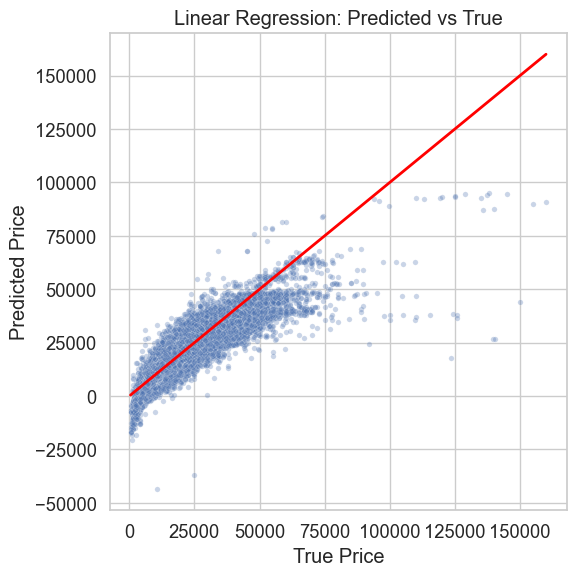

In [ ]:
plot_pred_vs_true(linreg_final, "Linear Regression")

Deviations from the diagonal line show systematic bias, specially under-predictions. Low-priced cars tend to be well-ish predicted, while **higher-priced cars are increasingly under-predicted**. The spread grows with price, indicating **heteroskedasticity and limited linear fit** at the most expensive cars.

An important takeaway from this plot is that negative values are being predicted, which does not make sense.

### 4.2. Residuals vs Predicted (heteroscedasticity check)

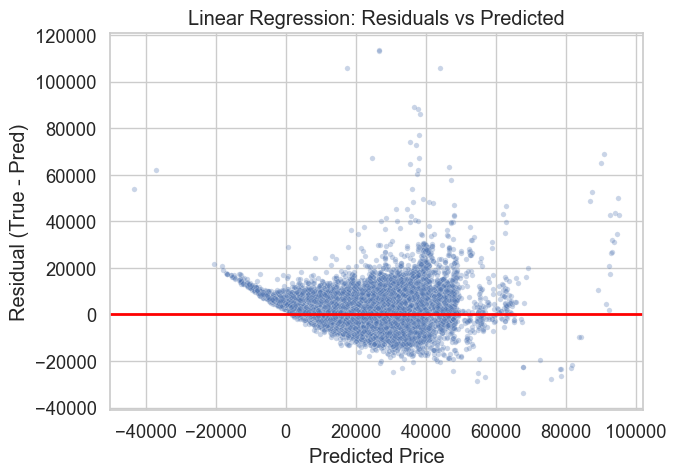

In [ ]:
plot_residuals(linreg_final, "Linear Regression")

Residuals are not randomly scattered: variance increases with predicted price, confirming heteroskedasticity. This structured pattern indicates that **linearity assumptions are violated** and that the model struggles with nonlinear price dynamics.

### 4.3. Residual distribution

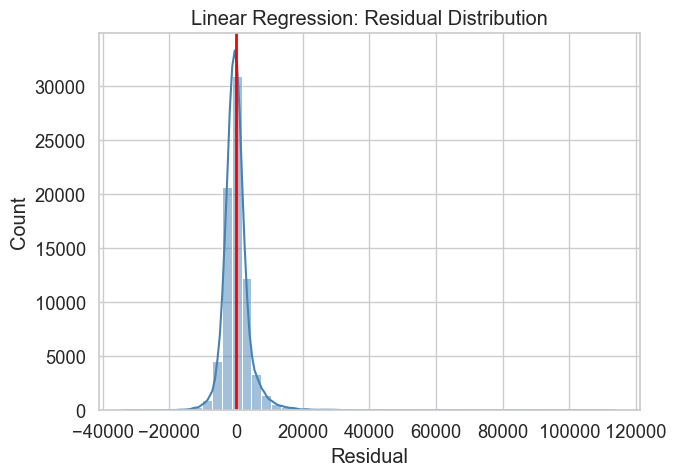

In [ ]:
plot_residual_distribution(linreg_final, "Linear Regression")

Residuals form a roughly centered distribution but with heavy tails, showing **large occasional errors**. The red zero-line highlights that although the mean residual is near zero, variance is high, especially on the positive side. This reflects **inconsistent accuracy** across different price ranges.

### 4.4. Permutation Importance

/var/folders/ts/9fy52qg56jz05nxpdkmswkzw0000gr/T/ipykernel_69263/1642101754.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="magma")


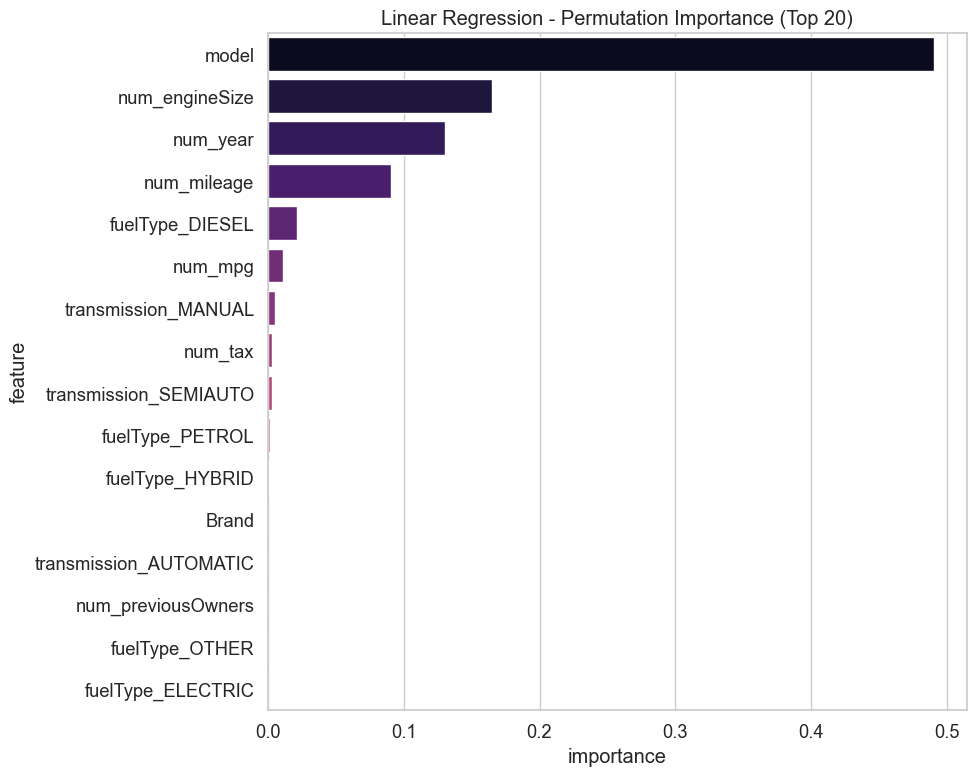

In [ ]:
plot_permutation_importance(linreg_final, "Linear Regression")

**`Model` identity dominates prediction power**, followed by `engine size`, `year`, and `mileage`. `Fuel type` and `transmission` contribute modestly. `Brand` has low importance because its information is already captured through model. Overall, the model relies heavily on a small group of numeric and categorical predictors.

### 4.5. SHAP


SHAP for Linear Regression (sample size = 2000)


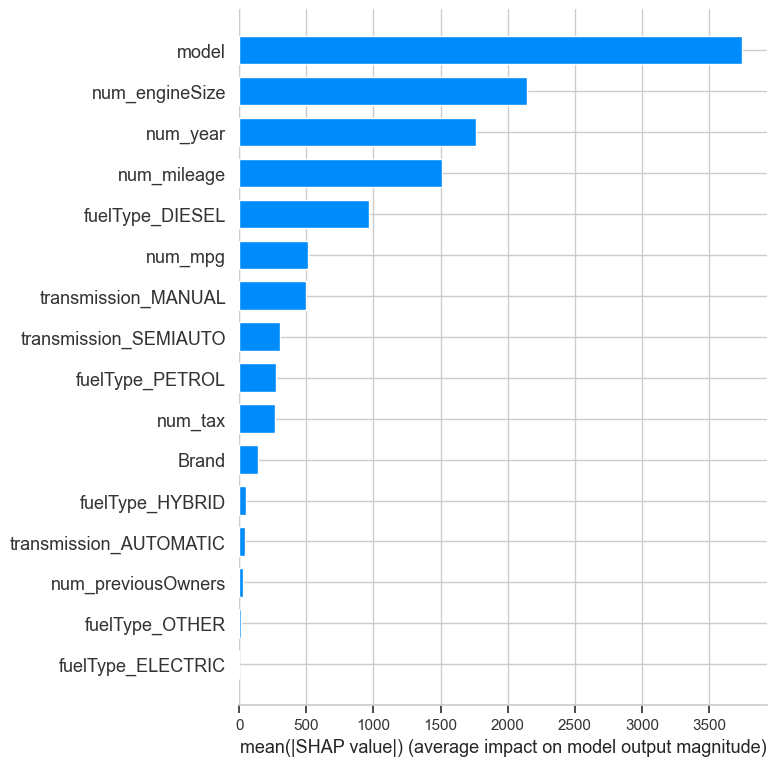

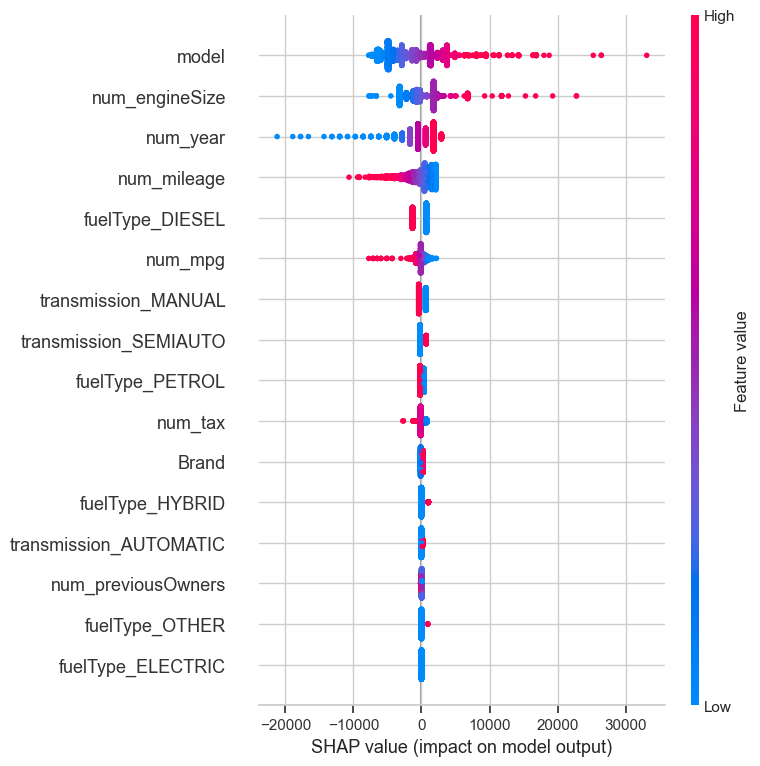

In [4]:
X_shap = X_full_final.copy()
X_shap = X_shap.astype(float)  # converts bool to 0/1 and ensures consistent dtype

apply_shap(linreg_final, X_shap, "Linear Regression")

- **Barplot:**<br>
SHAP confirms the same ranking: `model` is the strongest driver of prediction, with `engine size`, `year`, and `mileage` next. Diesel fuel type consistently increases predicted price, while `mpg` and `tax` have smaller but meaningful contributions. 

- **Beewarm:**<br>
Each top feature shows clear directional effects: **newer cars, larger engines, and lower mileage push predictions upward**, while older cars and high mileage lower them. Feature impacts are asymmetric, especially for `model` and `engine size`. Most low-ranked features show tightly centered SHAP values, confirming minimal effect.

# Ridge Regression 

### __Introduction__

Ridge Regression extends the linear model by adding an L2 penalty that shrinks coefficients toward zero.

This regularization reduces variance and stabilizes the model in the presence of multicollinearity (something that often occurs between `year` and `mileage`, for example).

Ridge preserves all features but prevents any single predictor from dominating the solution, making it a useful refinement over standard Linear Regression.

## 2. Randomized Hyperparameter Search with K-Fold Cross-Validation

In [ ]:
valid_transmissions = ["MANUAL", "AUTOMATIC", "SEMIAUTO"]
valid_fueltypes    = ["PETROL", "DIESEL", "HYBRID"]

# KFold config
N_SPLITS = 8
RANDOM_STATE = 42

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Hyperparameter space for Ridge
ridge_param_distributions = {
    #"alpha": np.logspace(-3, 3, 40)  # 1e-3 to 1e3
    "alpha": np.logspace(-5, 1, 200)  # testing lower alphas since standard linear regression performed better than ridge with higher alphas
}

N_RANDOM_CONFIGS_RIDGE = 40

ridge_sampler = ParameterSampler(
    ridge_param_distributions,
    n_iter=N_RANDOM_CONFIGS_RIDGE,
    random_state=RANDOM_STATE
)

ridge_search_results = []

# Best configs
ridge_best_rmse = np.inf
ridge_best_config_rmse = None

ridge_best_mae = np.inf
ridge_best_config_mae = None

ridge_best_combo = np.inf
ridge_best_config_combo = None

ridge_log_path = "ridge_random_search_log.txt"

with open(ridge_log_path, "w", encoding="utf-8") as log_file:

    def log_ridge(msg: str):
        log_file.write(datetime.now().strftime("[%Y-%m-%d %H:%M:%S] ") + msg + "\n")
        log_file.flush()

    log_ridge("# =============================")
    log_ridge("# START OF RANDOM SEARCH Ridge")
    log_ridge("# =============================")
    log_ridge(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {N_RANDOM_CONFIGS_RIDGE}")
    log_ridge(f"param_distributions = {ridge_param_distributions}")

    for config_id, params in enumerate(ridge_sampler, start=1):
        log_ridge("")
        log_ridge(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS_RIDGE} ########")
        log_ridge(f"Parameters: {params}")

        fold_rmses_val = []
        fold_maes_val  = []
        fold_r2s_val   = []
        fold_bias_val  = []

        fold_rmses_tr = []
        fold_maes_tr  = []
        fold_r2s_tr   = []
        fold_bias_tr  = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            log_ridge("")
            log_ridge(f"[CONFIG {config_id}] ==== FOLD {fold}/{N_SPLITS} ====")

            # 1) split
            X_train = X.iloc[train_idx].copy()
            X_val   = X.iloc[val_idx].copy()
            y_train = y.iloc[train_idx].copy()
            y_val   = y.iloc[val_idx].copy()

            log_ridge(f"[C{config_id}|F{fold}] X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")
            log_ridge(f"[C{config_id}|F{fold}] y_train shape: {y_train.shape}, y_val shape: {y_val.shape}")

            # NaNs before numeric imputation
            log_ridge(f"[C{config_id}|F{fold}] NaNs before numeric imputation (num features):")
            log_ridge(str(X_train[numeric_features].isna().sum()))

            log_ridge(f"[C{config_id}|F{fold}] NaNs before (categoricals):")
            log_ridge(str(X_train[categorical_features].isna().sum()))

            unknown_counts_before = (X_train[categorical_features] == "UNKNOWN").sum()
            log_ridge(f"[C{config_id}|F{fold}] 'UNKNOWN' before (categoricals):")
            log_ridge(str(unknown_counts_before))

            # 2) NUMERIC PREPROCESSING
            year_state = fit_year_median(
                X_train,
                year_col="year",
                model_col="model"
            )
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(
                X_train,
                mileage_col="mileage",
                do_abs=True
            )
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(
                X_train,
                engine_col="engineSize"
            )
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            tax_state = fit_tax_imputer(
                X_train,
                tax_col="tax",
                do_abs=True
            )
            X_train = transform_tax_imputer(X_train, state=tax_state)
            X_val   = transform_tax_imputer(X_val,   state=tax_state)

            mpg_state = fit_mpg_imputer(
                X_train,
                mpg_col="mpg",
                do_abs=True
            )
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            owners_state = fit_previous_owners_imputer(
                X_train,
                owners_col="previousOwners",
                year_col="year",
                mileage_col="mileage"
            )
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            log_ridge(f"[C{config_id}|F{fold}] After numeric imputation: X_train shape = {X_train.shape}, X_val shape = {X_val.shape}")
            log_ridge(f"[C{config_id}|F{fold}] NaNs after numeric imputation (num features):")
            log_ridge(str(X_train[numeric_features].isna().sum()))

            # 3) CATEGORICAL RESOLVERS
            brand_state = fit_ambiguous_brand_resolver(
                train_df=X_train,
                valid_brands=valid_brands,
                brand_col="Brand",
                model_col="model",
                year_col="year",
            )
            X_train, _, brand_still_invalid_train = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, brand_still_invalid_val   = transform_ambiguous_brands(X_val,   brand_state)
            log_ridge(f"[C{config_id}|F{fold}] After solving Brand - still invalid (train): {len(brand_still_invalid_train)}")

            model_state = fit_invalid_model_resolver(
                train_df=X_train,
                valid_models_by_brand=valid_models_by_brand,
                brand_col="Brand",
                model_col="model",
                year_col="year",
                fuel_col="fuelType",
                mpg_col="mpg",
            )
            X_train, _, model_still_invalid_train = transform_invalid_models(X_train, model_state)
            X_val,   _, model_still_invalid_val   = transform_invalid_models(X_val,   model_state)
            log_ridge(f"[C{config_id}|F{fold}] After solving model - still invalid (train): {len(model_still_invalid_train)}")

            transm_state = fit_transmission_resolver(
                train_df=X_train,
                valid_transmissions=valid_transmissions,
                transm_col="transmission",
                brand_col="Brand",
                model_col="model",
                fuel_col="fuelType",
            )
            X_train, _, transm_still_invalid_train = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, transm_still_invalid_val   = transform_transmission_resolver(X_val,   transm_state)
            log_ridge(f"[C{config_id}|F{fold}] After solving transmission - distinct (train): " +
                      str(sorted(X_train["transmission"].astype(str).str.upper().unique())))

            fuel_state = fit_fueltype_resolver(
                train_df=X_train,
                valid_fueltypes=valid_fueltypes,
                fuel_col="fuelType",
                brand_col="Brand",
                model_col="model",
                transm_col="transmission",
            )
            X_train, _, fuel_still_invalid_train = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, fuel_still_invalid_val   = transform_fueltype_resolver(X_val,   fuel_state)
            log_ridge(f"[C{config_id}|F{fold}] After solving fuelType - distinct (train): " +
                      str(sorted(X_train["fuelType"].astype(str).str.upper().unique())))

            # 4) CATEGORICAL ENCODING
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            log_ridge(f"[C{config_id}|F{fold}] high_card_features = {high_card_features}")
            log_ridge(f"[C{config_id}|F{fold}] low_card_features  = {low_card_features}")

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            log_ridge(f"[C{config_id}|F{fold}] X_train_cat shape: {X_train_cat.shape}")
            log_ridge(f"[C{config_id}|F{fold}] X_val_cat   shape: {X_val_cat.shape}")

            # 5) NUMERIC SCALING
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features])
            X_val_num   = scaler.transform(X_val[numeric_features])

            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features]
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features]
            )

            log_ridge(f"[C{config_id}|F{fold}] X_train_num_df shape: {X_train_num_df.shape}")
            log_ridge(f"[C{config_id}|F{fold}] X_val_num_df   shape: {X_val_num_df.shape}")

            # 6) FINAL MATRIX
            X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val_num_df,   X_val_cat],   axis=1)

            log_ridge(f"[C{config_id}|F{fold}] X_train_final shape: {X_train_final.shape}")
            log_ridge(f"[C{config_id}|F{fold}] X_val_final   shape: {X_val_final.shape}")

            # 7) RIDGE MODEL
            ridge = Ridge(
                alpha=params["alpha"],
                fit_intercept=True
            )

            log_ridge(f"[C{config_id}|F{fold}] Training Ridge...")
            ridge.fit(X_train_final, y_train)

            y_pred_train = ridge.predict(X_train_final)
            y_pred_val   = ridge.predict(X_val_final)

            # 8) METRICS
            mse_val  = mean_squared_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mse_val)
            mae_val  = mean_absolute_error(y_val, y_pred_val)
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = float(np.mean(y_pred_val - y_val))

            mse_tr  = mean_squared_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mse_tr)
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = float(np.mean(y_pred_train - y_train))

            log_ridge(f"[C{config_id}|F{fold}] TRAIN -> RMSE: {rmse_tr:.2f} | MAE: {mae_tr:.2f} | R2: {r2_tr:.4f} | Bias(pred-true): {bias_tr:.2f}")
            log_ridge(f"[C{config_id}|F{fold}] VAL   -> RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f} | R2: {r2_val:.4f} | Bias(pred-true): {bias_val:.2f}")

            fold_rmses_tr.append(rmse_tr)
            fold_maes_tr.append(mae_tr)
            fold_r2s_tr.append(r2_tr)
            fold_bias_tr.append(bias_tr)

            fold_rmses_val.append(rmse_val)
            fold_maes_val.append(mae_val)
            fold_r2s_val.append(r2_val)
            fold_bias_val.append(bias_val)

        # mean over folds
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_rmse_tr = np.mean(fold_rmses_tr)
        mean_mae_tr  = np.mean(fold_maes_tr)
        mean_r2_tr   = np.mean(fold_r2s_tr)
        mean_bias_tr = np.mean(fold_bias_tr)

        combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

        log_ridge("")
        log_ridge(f"Config {config_id} - Avg TRAIN RMSE: {mean_rmse_tr:.2f} | MAE: {mean_mae_tr:.2f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.2f}")
        log_ridge(f"Config {config_id} - Avg VAL   RMSE: {mean_rmse_val:.2f} | MAE: {mean_mae_val:.2f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.2f}")
        log_ridge(f"Config {config_id} - Combined score (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.2f}")

        ridge_search_results.append({
            "config_id": config_id,
            **params,
            "rmse_train_mean": mean_rmse_tr,
            "mae_train_mean": mean_mae_tr,
            "r2_train_mean": mean_r2_tr,
            "bias_train_mean": mean_bias_tr,
            "rmse_mean": mean_rmse_val,
            "mae_mean": mean_mae_val,
            "r2_mean": mean_r2_val,
            "bias_mean": mean_bias_val,
            "combo_score": combo_score,
        })

        # best by RMSE
        if mean_rmse_val < ridge_best_rmse:
            ridge_best_rmse = mean_rmse_val
            ridge_best_config_rmse = {**params}
            log_ridge(f"[NEW BEST RMSE] Config {config_id} with avg RMSE (VAL) = {ridge_best_rmse:.2f}")

        # best by MAE
        if mean_mae_val < ridge_best_mae:
            ridge_best_mae = mean_mae_val
            ridge_best_config_mae = {**params}
            log_ridge(f"[NEW BEST MAE] Config {config_id} with avg MAE (VAL) = {ridge_best_mae:.2f}")

        # best by combo
        if combo_score < ridge_best_combo:
            ridge_best_combo = combo_score
            ridge_best_config_combo = {**params}
            log_ridge(f"[NEW BEST COMBINED] Config {config_id} with score = {ridge_best_combo:.2f}")

    log_ridge("")
    log_ridge("# =============================")
    log_ridge("# END OF RANDOM SEARCH Ridge")
    log_ridge("# =============================")
    log_ridge(f"Best configuration (min RMSE VAL): {ridge_best_config_rmse}")
    log_ridge(f"Best average RMSE (VAL): {ridge_best_rmse:.2f}")
    log_ridge(f"Best configuration (min MAE VAL): {ridge_best_config_mae}")
    log_ridge(f"Best average MAE  (VAL): {ridge_best_mae:.2f}")
    log_ridge(f"Best configuration (combined score VAL): {ridge_best_config_combo}")
    log_ridge(f"Best combined score (VAL): {ridge_best_combo:.2f}")

ridge_results_df = pd.DataFrame(ridge_search_results)
ridge_results_df_sorted = ridge_results_df.sort_values(by="mae_mean", ascending=True)

display(ridge_results_df_sorted.head(10))

print("\nBest configuration found (min RMSE VAL):")
print(ridge_best_config_rmse)
print("Best average RMSE (VAL):", ridge_best_rmse)

print("\nBest configuration found (min MAE VAL):")
print(ridge_best_config_mae)
print("Best average MAE (VAL):", ridge_best_mae)

print("\nBest configuration found (min 0.5*RMSE + 0.5*MAE):")
print(ridge_best_config_combo)
print("Best combined score (VAL):", ridge_best_combo)

ridge_results_df_sorted.to_csv("ridge_random_search_results.csv", index=False)
print(f"\nDetailed logs in: {ridge_log_path}")

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.08472e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.10993e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.12801e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.18966e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/e

,config_id,alpha,rmse_train_mean,mae_train_mean,r2_train_mean,bias_train_mean,rmse_mean,mae_mean,r2_mean,bias_mean,combo_score
14,15,4.055461,4157.654526,2647.181024,0.817667,-2.043961e-14,4182.786724,2653.349385,0.815398,0.187673,3418.068055
11,12,3.072113,4157.653935,2647.194304,0.817667,-6.548194e-13,4182.790207,2653.366168,0.815398,0.187645,3418.078187
15,16,2.171118,4157.653385,2647.206683,0.817667,-3.113956e-14,4182.794614,2653.382788,0.815397,0.187717,3418.088701
8,9,1.762914,4157.653140,2647.212376,0.817667,2.537773e-14,4182.797169,2653.390869,0.815397,0.187803,3418.094019
7,8,1.335452,4157.652894,2647.218413,0.817667,7.643174e-13,4182.800360,2653.399829,0.815397,0.187949,3418.100094
12,13,0.943788,4157.652690,2647.224037,0.817667,4.514644e-14,4182.803883,2653.408600,0.815397,0.188153,3418.106241
38,39,0.880488,4157.652660,2647.224956,0.817667,3.041642e-14,4182.804518,2653.410078,0.815396,0.188194,3418.107298
3,4,0.580523,4157.652535,2647.229349,0.817667,3.678066e-13,4182.807823,2653.417368,0.815396,0.188426,3418.112596
17,18,0.382749,4157.652471,2647.232285,0.817667,1.996734e-13,4182.810313,2653.422471,0.815396,0.188620,3418.116392
34,35,0.333129,4157.652458,2647.233027,0.817667,-2.605915e-13,4182.810982,2653.423790,0.815396,0.188675,3418.117386



Best configuration found (min RMSE VAL):
{'alpha': np.float64(4.0554607358408274)}
Best average RMSE (VAL): 4182.78672438381

Best configuration found (min MAE VAL):
{'alpha': np.float64(4.0554607358408274)}
Best average MAE (VAL): 2653.349385014463

Best configuration found (min 0.5*RMSE + 0.5*MAE):
{'alpha': np.float64(4.0554607358408274)}
Best combined score (VAL): 3418.0680546991366

Detailed logs in: ridge_random_search_log.txt


## 3. Final Model Training and Kaggle Submission Generation

In [ ]:
# Choose final hyperparameters from Ridge search
final_config_ridge = ridge_best_config_rmse
#final_config_ridge = {
#    "alpha": ridge_best_config_rmse["alpha"]  
#}
print("Final Ridge config used for train:", final_config_ridge)

print("Preparing final Ridge Regression training...")

# 1) PREPARE FULL TRAIN FEATURES
X_full = X.copy()
y_full = y.copy()

# a) STRING NORMALIZATION 
cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]

for col in cols_to_normalize:
    if col in X_full.columns:
        X_full[col] = X_full[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

# Define feature sets
high_card_features = ["Brand", "model"] 
low_card_features  = [c for c in categorical_features if c not in high_card_features]

# 2) NUMERIC PRE PROCESSING - FULL TRAIN (FIT & TRANSFORM)
# Year
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

# Mileage
mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)

# Engine Size
engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)

# Tax
tax_state = fit_tax_imputer(X_full, tax_col="tax", do_abs=True)
X_full = transform_tax_imputer(X_full, state=tax_state)

# MPG
mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

# Paint Quality 
# paint_state = fit_paint_quality_imputer(X_full, paint_col="paintQuality%")
# X_full = transform_paint_quality_imputer(X_full, state=paint_state)

# Previous Owners
owners_state = fit_previous_owners_imputer(
    X_full, owners_col="previousOwners", year_col="year", mileage_col="mileage"
)
X_full = transform_previous_owners_imputer(X_full, state=owners_state)

# 3) CATEGORICAL RESOLVERS - FULL TRAIN (FIT & TRANSFORM)
# Brand
brand_state = fit_ambiguous_brand_resolver(
    train_df=X_full, valid_brands=valid_brands, 
    brand_col="Brand", model_col="model", year_col="year"
)
X_full, _, brand_still_invalid_full = transform_ambiguous_brands(X_full, brand_state)
print(f"Train full - Invalid Brands remaining: {len(brand_still_invalid_full)}")

# Model
model_state = fit_invalid_model_resolver(
    train_df=X_full, valid_models_by_brand=valid_models_by_brand,
    brand_col="Brand", model_col="model", year_col="year", 
    fuel_col="fuelType", mpg_col="mpg"
)
X_full, _, model_still_invalid_full = transform_invalid_models(X_full, model_state)
print(f"Train full - Invalid Models remaining: {len(model_still_invalid_full)}")

# Transmission
transm_state = fit_transmission_resolver(
    train_df=X_full, valid_transmissions=valid_transmissions,
    transm_col="transmission", brand_col="Brand", 
    model_col="model", fuel_col="fuelType"
)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

# Fuel Type
fuel_state = fit_fueltype_resolver(
    train_df=X_full, valid_fueltypes=valid_fueltypes,
    fuel_col="fuelType", brand_col="Brand", 
    model_col="model", transm_col="transmission"
)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

# 4) CATEGORICAL ENCODING - FULL TRAIN (FIT & TRANSFORM)
# Target Encoding
te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full)
X_full_high = te.transform(X_full[high_card_features])

# One-Hot Encoding
ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)
print("X_full_cat shape:", X_full_cat.shape)

# 5) NUMERIC SCALING - FULL TRAIN (FIT & TRANSFORM)
scaler = StandardScaler()
X_full_num = scaler.fit_transform(X_full[numeric_features])

X_full_num_df = pd.DataFrame(
    X_full_num,
    index=X_full.index,
    columns=[f"num_{col}" for col in numeric_features]
)
print("X_full_num_df shape:", X_full_num_df.shape)

# 6) FINAL MATRIX - FULL TRAIN
X_full_final = pd.concat([X_full_num_df, X_full_cat], axis=1)
print("X_full_final shape:", X_full_final.shape)

# 7) TRAIN FINAL RIDGE REGRESSION MODEL
ridge_final = Ridge(
    alpha=final_config_ridge["alpha"],
    fit_intercept=True
)

print("Training final Ridge Regression model on full data...")
ridge_final.fit(X_full_final, y_full)
print("Done.")

# 8) PREPARE TEST FEATURES
test_df = pd.read_csv("../../project_data/test.csv")

# a) STRING NORMALIZATION (same logic as train)
for col in cols_to_normalize:
    if col in test_df.columns:
        test_df[col] = test_df[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

X_test = test_df[numeric_features + categorical_features].copy()

# b) NUMERIC PREPROCESSING - TEST (TRANSFORM ONLY)
X_test = transform_year_with_model_median(X_test, state=year_state)
X_test = transform_mileage_imputer(X_test, state=mileage_state)
X_test = transform_engine_size_imputer(X_test, state=engine_state)
X_test = transform_tax_imputer(X_test, state=tax_state)
X_test = transform_mpg_imputer(X_test, state=mpg_state)
# X_test = transform_paint_quality_imputer(X_test, state=paint_state)
X_test = transform_previous_owners_imputer(X_test, state=owners_state)

# c) CATEGORICAL RESOLVERS - TEST (TRANSFORM ONLY)
X_test, _, _ = transform_ambiguous_brands(X_test, brand_state)
X_test, _, _ = transform_invalid_models(X_test, model_state)
X_test, _, _ = transform_transmission_resolver(X_test, transm_state)
X_test, _, _ = transform_fueltype_resolver(X_test, fuel_state)

# d) ENCODING - TEST (TRANSFORM ONLY)
X_test_high = te.transform(X_test[high_card_features])
X_test_low  = ohe.transform(X_test[low_card_features])
X_test_cat  = pd.concat([X_test_high, X_test_low], axis=1)

# e) SCALING - TEST (TRANSFORM ONLY)
X_test_num = scaler.transform(X_test[numeric_features])
X_test_num_df = pd.DataFrame(
    X_test_num,
    index=X_test.index,
    columns=[f"num_{col}" for col in numeric_features]
)

# 9) FINAL MATRIX & PREDICTION
X_test_final = pd.concat([X_test_num_df, X_test_cat], axis=1)

# Ensure same column order as training
X_test_final = X_test_final[X_full_final.columns]

print("X_test_final shape:", X_test_final.shape)

y_test_pred = ridge_final.predict(X_test_final)

print("Predictions summary (float):")
print(pd.Series(y_test_pred).describe())

# Optional rounding
y_test_pred_round = np.round(y_test_pred).astype(int)

submission = pd.DataFrame({
    "carID": test_df["carID"].astype(int),
    "price": y_test_pred  
})

sub_name = f"ridge_regression_final_submission_alpha{final_config_ridge['alpha']:.4f}.csv"
submission.to_csv(sub_name, index=False)
print(f"Submission file created: {sub_name}")

Final Ridge config used for train: {'alpha': np.float64(4.0554607358408274)}
Preparing final Ridge Regression training...
Train full - Invalid Brands remaining: 0
Train full - Invalid Models remaining: 1
X_full_cat shape: (75973, 10)
X_full_num_df shape: (75973, 6)
X_full_final shape: (75973, 16)
Training final Ridge Regression model on full data...
Done.
X_test_final shape: (32567, 16)
Predictions summary (float):
count    32567.000000
mean     16897.847284
std       8754.320901
min     -19434.986963
25%      10847.605371
50%      15467.654111
75%      22289.286945
max      95041.954828
dtype: float64
Submission file created: ridge_regression_final_submission_alpha4.0555.csv


## 4. Visualizations

### 4.1. Predicted vs true

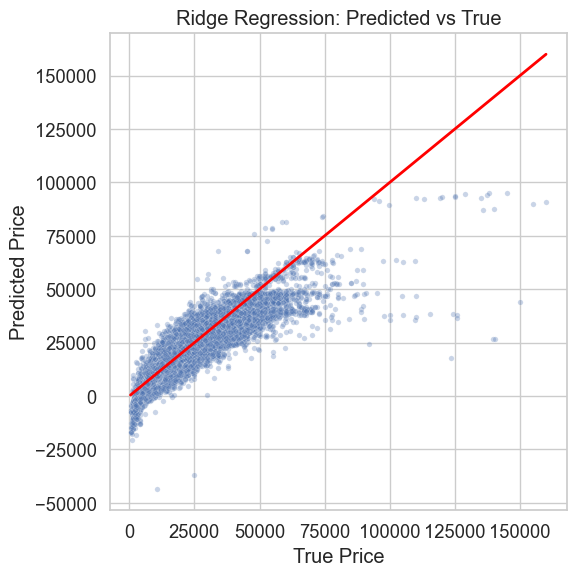

In [ ]:
plot_pred_vs_true(ridge_final, "Ridge Regression")

### 4.2. Residuals vs Predicted (heteroscedasticity check)

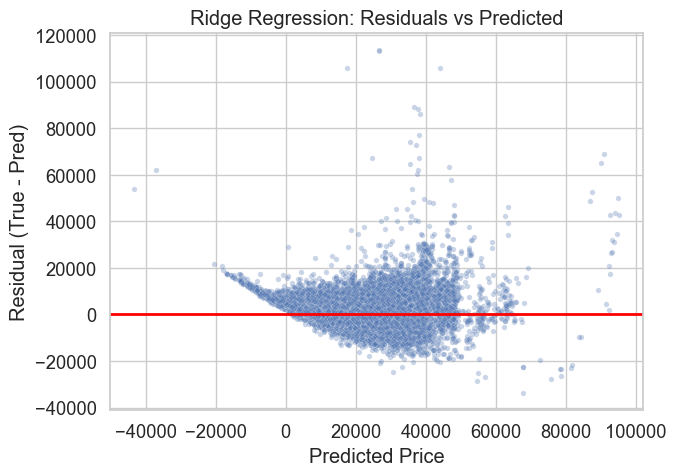

In [ ]:
plot_residuals(ridge_final, "Ridge Regression")

### 4.3. Residual distribution

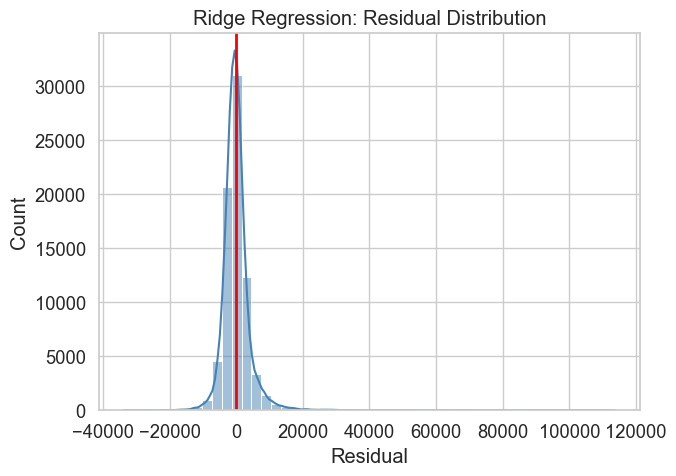

In [ ]:
plot_residual_distribution(ridge_final, "Ridge Regression")

### 4.4. Permutation Importance

/var/folders/ts/9fy52qg56jz05nxpdkmswkzw0000gr/T/ipykernel_71162/2081930191.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="magma")


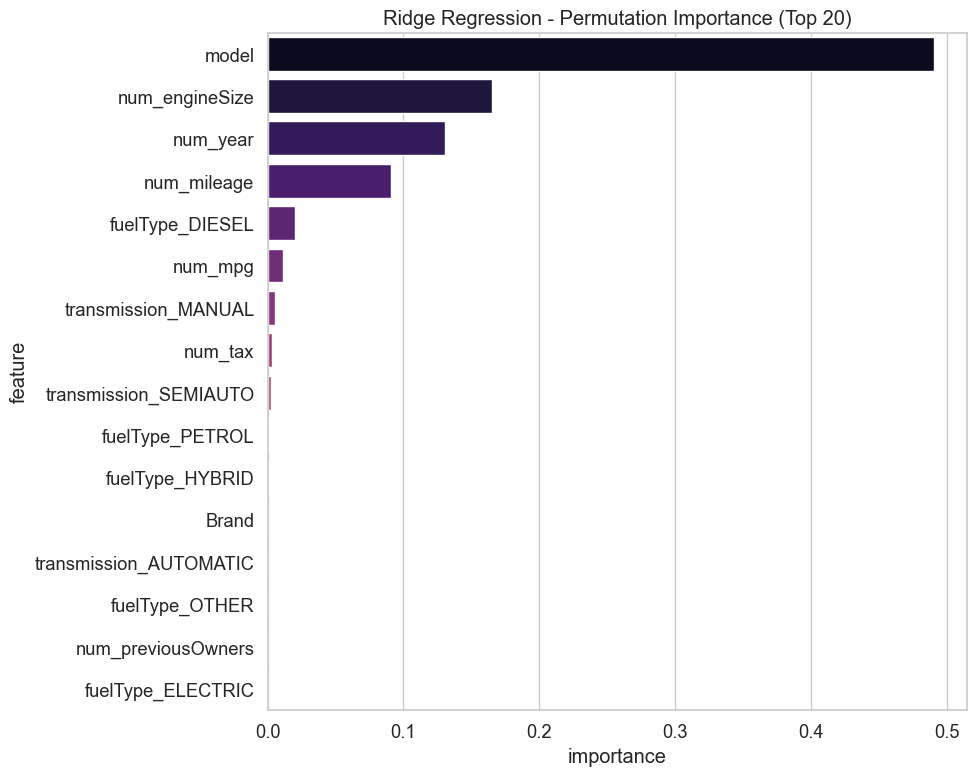

In [ ]:
plot_permutation_importance(ridge_final, "Ridge Regression")

### 4.5. SHAP


SHAP for Ridge Regression (sample size = 2000)


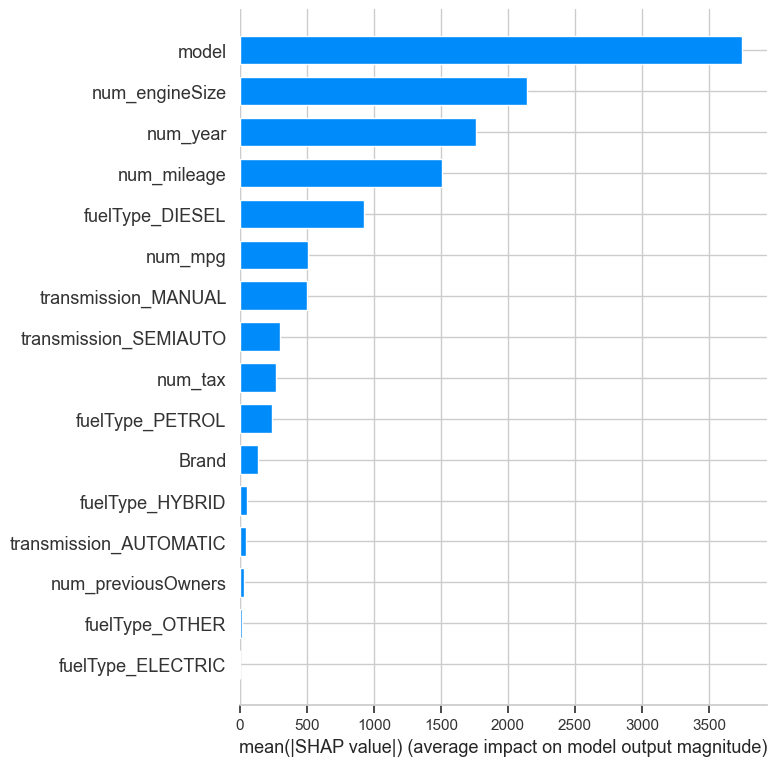

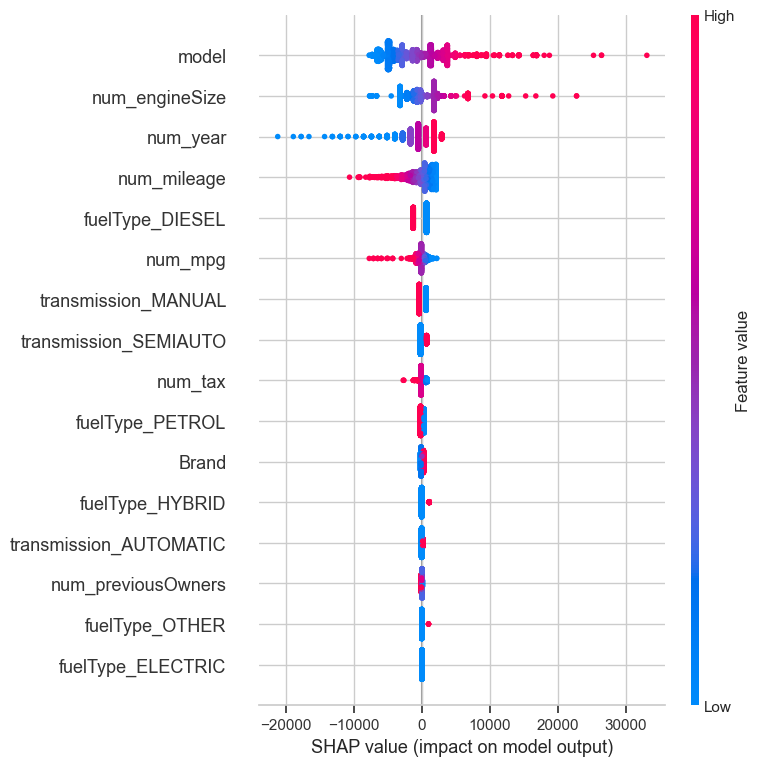

In [ ]:
X_shap = X_full_final.copy()
X_shap = X_shap.astype(float)  # converts bool to 0/1 and ensures consistent dtype

apply_shap(ridge_final, X_shap, "Ridge Regression")

# Lasso Regression 

### __Introduction__

Lasso introduces an L1 penalty, which can shrink some coefficients exactly to zero. This produces a simpler, more interpretable model and effectively performs embedded feature selection.

In our workflow, Lasso helps determine whether a sparser representation of the data can generalize better than both the unregularized model and Ridge, especially in the presence of noisy or weak predictors.

## 2. Randomized Hyperparameter Search with K-Fold Cross-Validation

In [ ]:
valid_transmissions = ["MANUAL", "AUTOMATIC", "SEMIAUTO"]
valid_fueltypes    = ["PETROL", "DIESEL", "HYBRID"]

# KFold config
N_SPLITS = 8
RANDOM_STATE = 42

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

lasso_param_distributions = {
    #"alpha": np.logspace(-3, 1, 40)  # 1e-3 to 10
    "alpha": np.logspace(-5, 1, 200)  # testing lower alphas since standard linear regression performed better than lasso with higher alphas
}

N_RANDOM_CONFIGS_LASSO = 50

lasso_sampler = ParameterSampler(
    lasso_param_distributions,
    n_iter=N_RANDOM_CONFIGS_LASSO,
    random_state=RANDOM_STATE
)

lasso_search_results = []

lasso_best_rmse = np.inf
lasso_best_config_rmse = None

lasso_best_mae = np.inf
lasso_best_config_mae = None

lasso_best_combo = np.inf
lasso_best_config_combo = None

lasso_log_path = "lasso_random_search_log.txt"

with open(lasso_log_path, "w", encoding="utf-8") as log_file:

    def log_lasso(msg: str):
        log_file.write(datetime.now().strftime("[%Y-%m-%d %H:%M:%S] ") + msg + "\n")
        log_file.flush()

    log_lasso("# =============================")
    log_lasso("# START OF RANDOM SEARCH Lasso")
    log_lasso("# =============================")
    log_lasso(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {N_RANDOM_CONFIGS_LASSO}")
    log_lasso(f"param_distributions = {lasso_param_distributions}")

    for config_id, params in enumerate(lasso_sampler, start=1):
        log_lasso("")
        log_lasso(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS_LASSO} ########")
        log_lasso(f"Parameters: {params}")

        fold_rmses_val = []
        fold_maes_val  = []
        fold_r2s_val   = []
        fold_bias_val  = []

        fold_rmses_tr = []
        fold_maes_tr  = []
        fold_r2s_tr   = []
        fold_bias_tr  = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            log_lasso("")
            log_lasso(f"[CONFIG {config_id}] ==== FOLD {fold}/{N_SPLITS} ====")

            X_train = X.iloc[train_idx].copy()
            X_val   = X.iloc[val_idx].copy()
            y_train = y.iloc[train_idx].copy()
            y_val   = y.iloc[val_idx].copy()

            log_lasso(f"[C{config_id}|F{fold}] X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")
            log_lasso(f"[C{config_id}|F{fold}] y_train shape: {y_train.shape}, y_val shape: {y_val.shape}")

            # numeric imputers
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            tax_state = fit_tax_imputer(X_train, tax_col="tax", do_abs=True)
            X_train = transform_tax_imputer(X_train, state=tax_state)
            X_val   = transform_tax_imputer(X_val,   state=tax_state)

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            owners_state = fit_previous_owners_imputer(
                X_train, owners_col="previousOwners", year_col="year", mileage_col="mileage"
            )
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            # resolvers
            brand_state = fit_ambiguous_brand_resolver(
                train_df=X_train, valid_brands=valid_brands,
                brand_col="Brand", model_col="model", year_col="year"
            )
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

            model_state = fit_invalid_model_resolver(
                train_df=X_train, valid_models_by_brand=valid_models_by_brand,
                brand_col="Brand", model_col="model", year_col="year",
                fuel_col="fuelType", mpg_col="mpg"
            )
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val,   _, _ = transform_invalid_models(X_val,   model_state)

            transm_state = fit_transmission_resolver(
                train_df=X_train, valid_transmissions=valid_transmissions,
                transm_col="transmission", brand_col="Brand",
                model_col="model", fuel_col="fuelType"
            )
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

            fuel_state = fit_fueltype_resolver(
                train_df=X_train, valid_fueltypes=valid_fueltypes,
                fuel_col="fuelType", brand_col="Brand",
                model_col="model", transm_col="transmission"
            )
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

            # encoding
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # scaling
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features])
            X_val_num   = scaler.transform(X_val[numeric_features])

            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features]
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features]
            )

            X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val_num_df,   X_val_cat],   axis=1)

            # model
            lasso = Lasso(
                alpha=params["alpha"],
                fit_intercept=True,
                max_iter=10000
            )

            log_lasso(f"[C{config_id}|F{fold}] Training Lasso...")
            lasso.fit(X_train_final, y_train)

            y_pred_train = lasso.predict(X_train_final)
            y_pred_val   = lasso.predict(X_val_final)

            mse_val  = mean_squared_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mse_val)
            mae_val  = mean_absolute_error(y_val, y_pred_val)
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = float(np.mean(y_pred_val - y_val))

            mse_tr  = mean_squared_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mse_tr)
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = float(np.mean(y_pred_train - y_train))

            log_lasso(f"[C{config_id}|F{fold}] TRAIN -> RMSE: {rmse_tr:.2f} | MAE: {mae_tr:.2f} | R2: {r2_tr:.4f} | Bias(pred-true): {bias_tr:.2f}")
            log_lasso(f"[C{config_id}|F{fold}] VAL   -> RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f} | R2: {r2_val:.4f} | Bias(pred-true): {bias_val:.2f}")

            fold_rmses_tr.append(rmse_tr)
            fold_maes_tr.append(mae_tr)
            fold_r2s_tr.append(r2_tr)
            fold_bias_tr.append(bias_tr)

            fold_rmses_val.append(rmse_val)
            fold_maes_val.append(mae_val)
            fold_r2s_val.append(r2_val)
            fold_bias_val.append(bias_val)

        # mean over folds
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_rmse_tr = np.mean(fold_rmses_tr)
        mean_mae_tr  = np.mean(fold_maes_tr)
        mean_r2_tr   = np.mean(fold_r2s_tr)
        mean_bias_tr = np.mean(fold_bias_tr)

        combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

        log_lasso(f"Config {config_id} - Avg TRAIN RMSE: {mean_rmse_tr:.2f} | MAE: {mean_mae_tr:.2f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.2f}")
        log_lasso(f"Config {config_id} - Avg VAL   RMSE: {mean_rmse_val:.2f} | MAE: {mean_mae_val:.2f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.2f}")
        log_lasso(f"Config {config_id} - Combined score (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.2f}")

        lasso_search_results.append({
            "config_id": config_id,
            **params,
            "rmse_train_mean": mean_rmse_tr,
            "mae_train_mean": mean_mae_tr,
            "r2_train_mean": mean_r2_tr,
            "bias_train_mean": mean_bias_tr,
            "rmse_mean": mean_rmse_val,
            "mae_mean": mean_mae_val,
            "r2_mean": mean_r2_val,
            "bias_mean": mean_bias_val,
            "combo_score": combo_score,
        })

        if mean_rmse_val < lasso_best_rmse:
            lasso_best_rmse = mean_rmse_val
            lasso_best_config_rmse = {**params}
            log_lasso(f"[NEW BEST RMSE] Config {config_id} with avg RMSE (VAL) = {lasso_best_rmse:.2f}")

        if mean_mae_val < lasso_best_mae:
            lasso_best_mae = mean_mae_val
            lasso_best_config_mae = {**params}
            log_lasso(f"[NEW BEST MAE] Config {config_id} with avg MAE (VAL) = {lasso_best_mae:.2f}")

        if combo_score < lasso_best_combo:
            lasso_best_combo = combo_score
            lasso_best_config_combo = {**params}
            log_lasso(f"[NEW BEST COMBINED] Config {config_id} with score = {lasso_best_combo:.2f}")

    log_lasso("")
    log_lasso("# =============================")
    log_lasso("# END OF RANDOM SEARCH Lasso")
    log_lasso("# =============================")
    log_lasso(f"Best configuration (min RMSE VAL): {lasso_best_config_rmse}")
    log_lasso(f"Best average RMSE (VAL): {lasso_best_rmse:.2f}")
    log_lasso(f"Best configuration (min MAE VAL): {lasso_best_config_mae}")
    log_lasso(f"Best average MAE  (VAL): {lasso_best_mae:.2f}")
    log_lasso(f"Best configuration (combined score VAL): {lasso_best_config_combo}")
    log_lasso(f"Best combined score (VAL): {lasso_best_combo:.2f}")

lasso_results_df = pd.DataFrame(lasso_search_results)
lasso_results_df_sorted = lasso_results_df.sort_values(by="mae_mean", ascending=True)

display(lasso_results_df_sorted.head(10))

print("\nBest configuration found (min RMSE VAL):")
print(lasso_best_config_rmse)
print("Best average RMSE (VAL):", lasso_best_rmse)

print("\nBest configuration found (min MAE VAL):")
print(lasso_best_config_mae)
print("Best average MAE (VAL):", lasso_best_mae)

print("\nBest configuration found (min 0.5*RMSE + 0.5*MAE):")
print(lasso_best_config_combo)
print("Best combined score (VAL):", lasso_best_combo)

lasso_results_df_sorted.to_csv("lasso_random_search_results.csv", index=False)
print(f"\nDetailed logs in: {lasso_log_path}")## 3. Final Model Training and Kaggle Submission Generation

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.348e+11, tolerance: 6.343e+08
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.341e+11, tolerance: 6.312e+08
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing reg

,config_id,alpha,rmse_train_mean,mae_train_mean,r2_train_mean,bias_train_mean,rmse_mean,mae_mean,r2_mean,bias_mean,combo_score
41,42,8.703591,4159.280031,2643.784649,0.817525,2.200518e-13,4184.220546,2649.918691,0.815269,0.166447,3417.069619
45,46,7.575250,4159.143489,2644.204527,0.817537,2.020377e-13,4184.061388,2650.327843,0.815284,0.167229,3417.194616
14,15,4.055461,4158.839148,2645.641220,0.817563,3.111037e-13,4183.687811,2651.747901,0.815317,0.169634,3417.717856
11,12,3.072113,4158.707708,2645.996457,0.817575,7.234764e-13,4183.598139,2652.160843,0.815325,0.154976,3417.879491
15,16,2.171118,4158.439994,2646.199336,0.817598,9.153965e-13,4183.370324,2652.399602,0.815345,0.151244,3417.884963
8,9,1.762914,4158.331344,2646.318006,0.817608,4.496883e-13,4183.254144,2652.510308,0.815356,0.156029,3417.882226
7,8,1.335452,4158.239147,2646.483672,0.817616,3.498003e-13,4183.150189,2652.641019,0.815365,0.148173,3417.895604
12,13,0.943788,4158.180140,2646.660925,0.817621,9.632963e-13,4183.083131,2652.803768,0.815371,0.148855,3417.943450
38,39,0.880488,4158.172652,2646.691623,0.817622,1.083245e-12,4183.074780,2652.832901,0.815372,0.149115,3417.953840
3,4,0.580523,4158.143585,2646.844263,0.817624,9.110138e-14,4183.039280,2652.980555,0.815375,0.149970,3418.009918



Best configuration found (min RMSE VAL):
{'alpha': np.float64(0.029331662783900425)}
Best average RMSE (VAL): 4183.001158527533

Best configuration found (min MAE VAL):
{'alpha': np.float64(8.703591361485167)}
Best average MAE (VAL): 2649.9186914662296

Best configuration found (min 0.5*RMSE + 0.5*MAE):
{'alpha': np.float64(8.703591361485167)}
Best combined score (VAL): 3417.069618847616

Detailed logs in: lasso_random_search_log.txt


## 3. Final Model Training and Kaggle Submission Generation

In [ ]:
# Choose final hyperparameters 
final_config_lasso = lasso_best_config_rmse
#final_config_lasso = {
#    "alpha": lasso_best_config_rmse["alpha"]
#}
print("Final Lasso config used for train:", final_config_lasso)

print("Preparing final Lasso Regression training...")

# 1) PREPARE FULL TRAIN FEATURES
X_full = X.copy()
y_full = y.copy()

# a) STRING NORMALIZATION
cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]

for col in cols_to_normalize:
    if col in X_full.columns:
        X_full[col] = X_full[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

# Feature sets
high_card_features = ["Brand", "model"] 
low_card_features  = [c for c in categorical_features if c not in high_card_features]

# 2) NUMERIC PRE PROCESSING - FULL TRAIN
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)

engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)

tax_state = fit_tax_imputer(X_full, tax_col="tax", do_abs=True)
X_full = transform_tax_imputer(X_full, state=tax_state)

mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

# paint_state = fit_paint_quality_imputer(X_full, paint_col="paintQuality%")
# X_full = transform_paint_quality_imputer(X_full, state=paint_state)

owners_state = fit_previous_owners_imputer(
    X_full, owners_col="previousOwners", year_col="year", mileage_col="mileage"
)
X_full = transform_previous_owners_imputer(X_full, state=owners_state)

# 3) CATEGORICAL RESOLVERS - FULL TRAIN
brand_state = fit_ambiguous_brand_resolver(
    train_df=X_full, valid_brands=valid_brands, 
    brand_col="Brand", model_col="model", year_col="year"
)
X_full, _, brand_still_invalid_full = transform_ambiguous_brands(X_full, brand_state)
print(f"Train full - Invalid Brands remaining: {len(brand_still_invalid_full)}")

model_state = fit_invalid_model_resolver(
    train_df=X_full, valid_models_by_brand=valid_models_by_brand,
    brand_col="Brand", model_col="model", year_col="year", 
    fuel_col="fuelType", mpg_col="mpg"
)
X_full, _, model_still_invalid_full = transform_invalid_models(X_full, model_state)
print(f"Train full - Invalid Models remaining: {len(model_still_invalid_full)}")

transm_state = fit_transmission_resolver(
    train_df=X_full, valid_transmissions=valid_transmissions,
    transm_col="transmission", brand_col="Brand", 
    model_col="model", fuel_col="fuelType"
)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

fuel_state = fit_fueltype_resolver(
    train_df=X_full, valid_fueltypes=valid_fueltypes,
    fuel_col="fuelType", brand_col="Brand", 
    model_col="model", transm_col="transmission"
)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

# 4) CATEGORICAL ENCODING - FULL TRAIN
te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full)
X_full_high = te.transform(X_full[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)
print("X_full_cat shape:", X_full_cat.shape)

# 5) NUMERIC SCALING - FULL TRAIN
scaler = StandardScaler()
X_full_num = scaler.fit_transform(X_full[numeric_features])

X_full_num_df = pd.DataFrame(
    X_full_num,
    index=X_full.index,
    columns=[f"num_{col}" for col in numeric_features]
)
print("X_full_num_df shape:", X_full_num_df.shape)

# 6) FINAL MATRIX - FULL TRAIN
X_full_final = pd.concat([X_full_num_df, X_full_cat], axis=1)
print("X_full_final shape:", X_full_final.shape)

# 7) TRAIN FINAL LASSO REGRESSION MODEL
lasso_final = Lasso(
    alpha=final_config_lasso["alpha"],
    fit_intercept=True,
    max_iter=10000
)

print("Training final Lasso Regression model on full data...")
lasso_final.fit(X_full_final, y_full)
print("Done.")

# 8) PREPARE TEST FEATURES
test_df = pd.read_csv("../../project_data/test.csv")

for col in cols_to_normalize:
    if col in test_df.columns:
        test_df[col] = test_df[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

X_test = test_df[numeric_features + categorical_features].copy()

# NUMERIC PREPROCESSING - TEST
X_test = transform_year_with_model_median(X_test, state=year_state)
X_test = transform_mileage_imputer(X_test, state=mileage_state)
X_test = transform_engine_size_imputer(X_test, state=engine_state)
X_test = transform_tax_imputer(X_test, state=tax_state)
X_test = transform_mpg_imputer(X_test, state=mpg_state)
# X_test = transform_paint_quality_imputer(X_test, state=paint_state)
X_test = transform_previous_owners_imputer(X_test, state=owners_state)

# CATEGORICAL RESOLVERS - TEST
X_test, _, _ = transform_ambiguous_brands(X_test, brand_state)
X_test, _, _ = transform_invalid_models(X_test, model_state)
X_test, _, _ = transform_transmission_resolver(X_test, transm_state)
X_test, _, _ = transform_fueltype_resolver(X_test, fuel_state)

# ENCODING - TEST
X_test_high = te.transform(X_test[high_card_features])
X_test_low  = ohe.transform(X_test[low_card_features])
X_test_cat  = pd.concat([X_test_high, X_test_low], axis=1)

# SCALING - TEST
X_test_num = scaler.transform(X_test[numeric_features])
X_test_num_df = pd.DataFrame(
    X_test_num,
    index=X_test.index,
    columns=[f"num_{col}" for col in numeric_features]
)

# FINAL MATRIX & PREDICTION
X_test_final = pd.concat([X_test_num_df, X_test_cat], axis=1)
X_test_final = X_test_final[X_full_final.columns]

print("X_test_final shape:", X_test_final.shape)

y_test_pred = lasso_final.predict(X_test_final)

print("Predictions summary (float):")
print(pd.Series(y_test_pred).describe())

y_test_pred_round = np.round(y_test_pred).astype(int)

submission = pd.DataFrame({
    "carID": test_df["carID"].astype(int),
    "price": y_test_pred  
})

sub_name = f"lasso_regression_final_submission_alpha{final_config_lasso['alpha']:.4f}.csv"
submission.to_csv(sub_name, index=False)
print(f"Submission file created: {sub_name}")

Final Lasso config used for train: {'alpha': np.float64(0.029331662783900425)}
Preparing final Lasso Regression training...
Train full - Invalid Brands remaining: 0
Train full - Invalid Models remaining: 1
X_full_cat shape: (75973, 10)
X_full_num_df shape: (75973, 6)
X_full_final shape: (75973, 16)
Training final Lasso Regression model on full data...


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.237e+11, tolerance: 7.203e+08
  model = cd_fast.enet_coordinate_descent(


Done.
X_test_final shape: (32567, 16)
Predictions summary (float):
count    32567.000000
mean     16897.771198
std       8754.059537
min     -19436.728454
25%      10847.945292
50%      15466.997860
75%      22288.773286
max      95040.747187
dtype: float64
Submission file created: lasso_regression_final_submission_alpha0.0293.csv


## 4. Visualizations

### 4.1. Predicted vs true

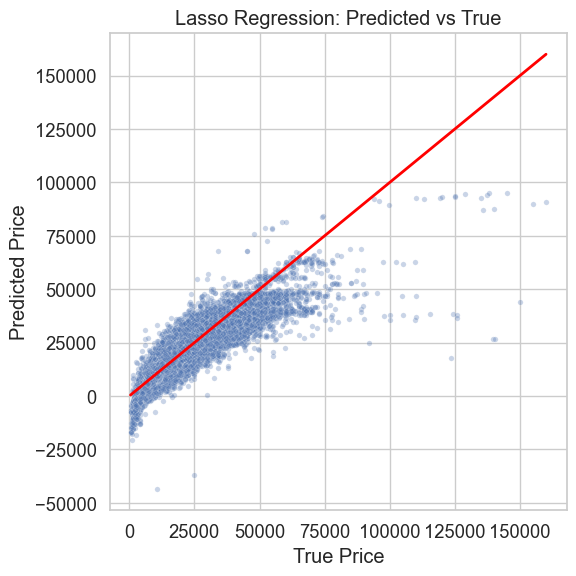

In [ ]:
plot_pred_vs_true(lasso_final, "Lasso Regression")

### 4.2. Residuals vs Predicted (heteroscedasticity check)

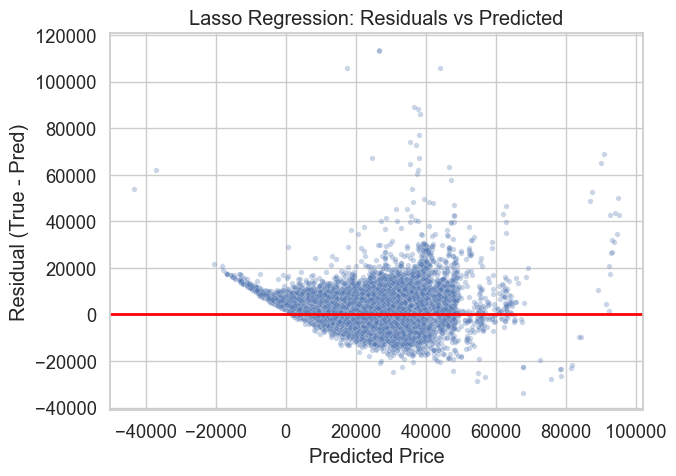

In [ ]:
plot_residuals(lasso_final, "Lasso Regression")

### 4.3. Residual distribution

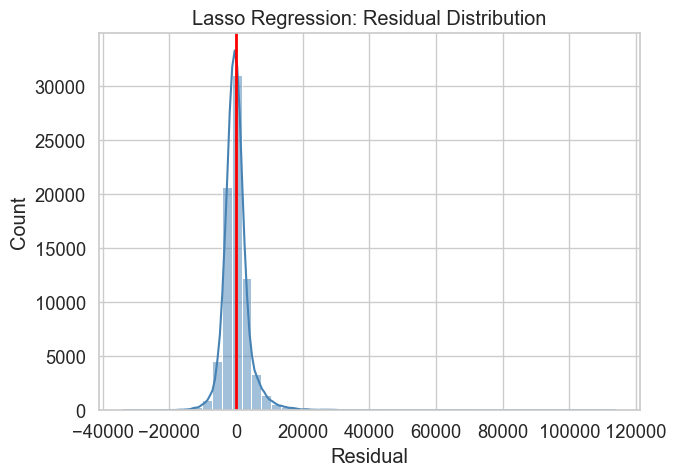

In [ ]:
plot_residual_distribution(lasso_final, "Lasso Regression")

### 4.4. Permutation Importance

/var/folders/ts/9fy52qg56jz05nxpdkmswkzw0000gr/T/ipykernel_71181/2081930191.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="magma")


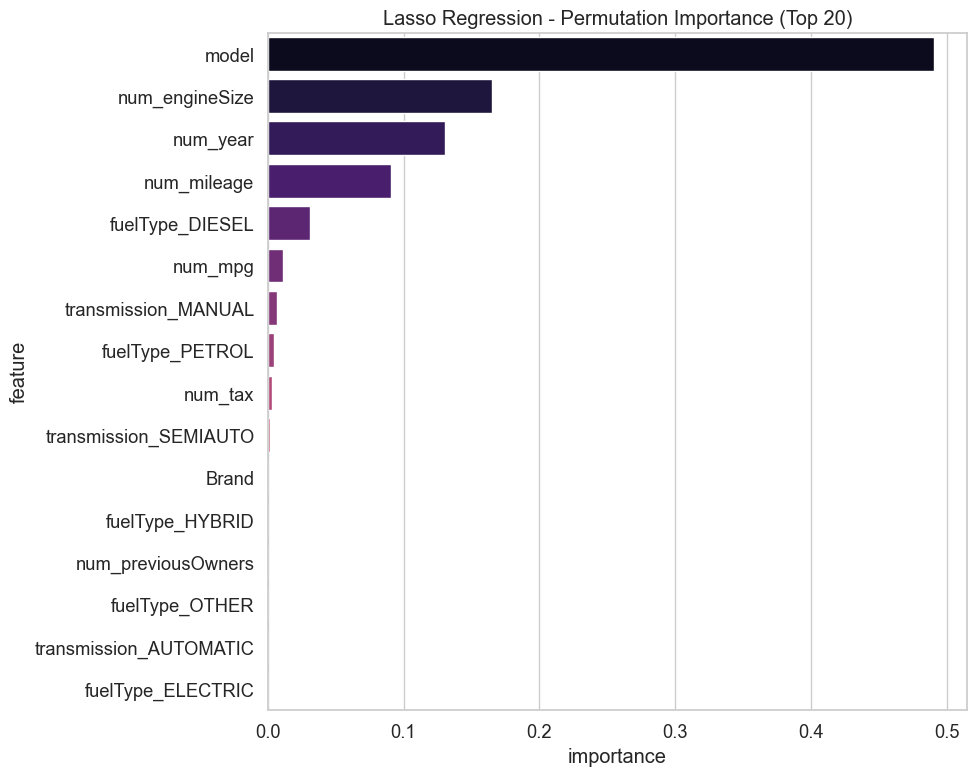

In [ ]:
plot_permutation_importance(lasso_final, "Lasso Regression")

### 4.5. SHAP


SHAP for Lasso Regression (sample size = 2000)


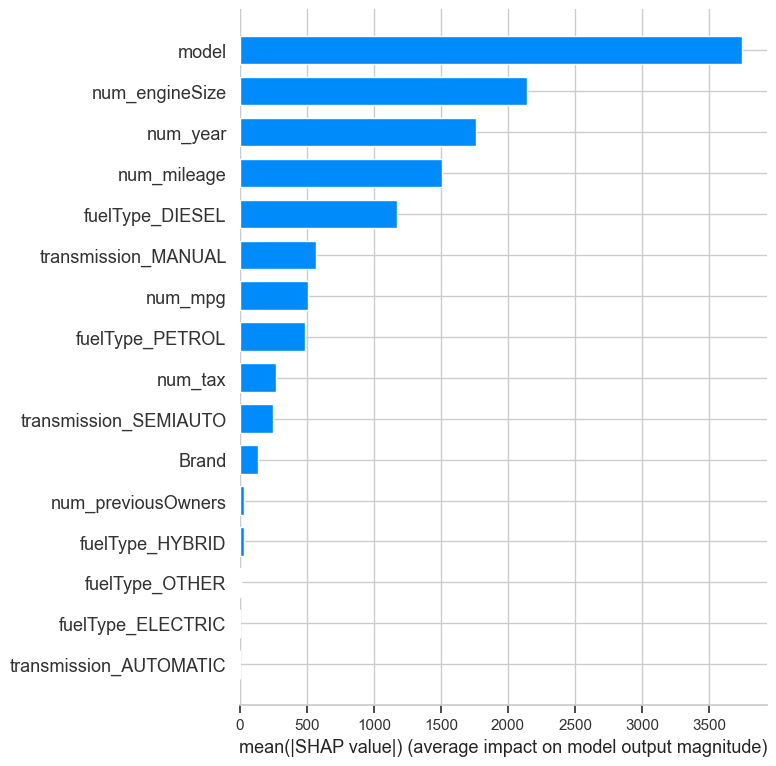

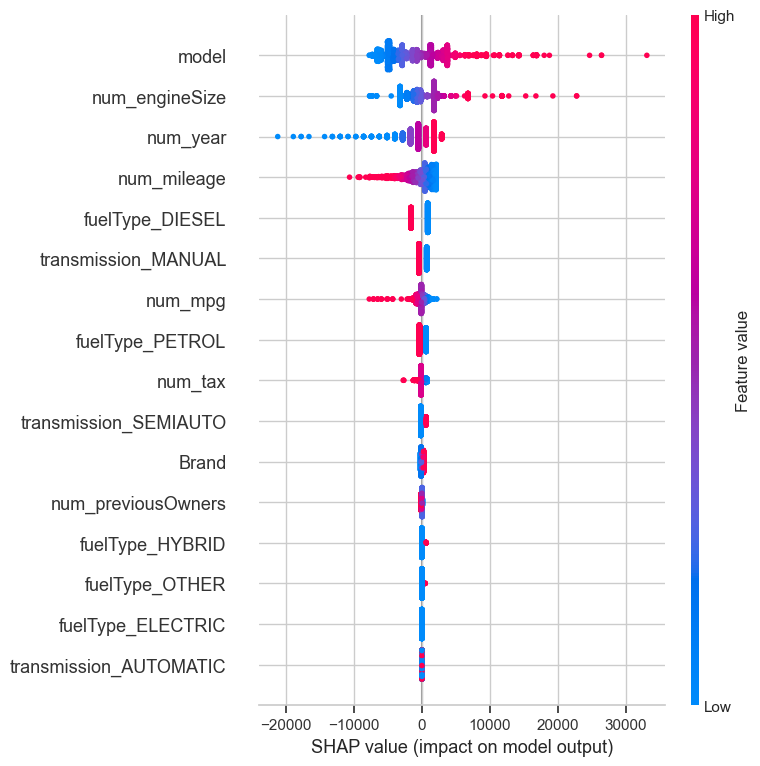

In [ ]:
X_shap = X_full_final.copy()
X_shap = X_shap.astype(float)  # converts bool to 0/1 and ensures consistent dtype

apply_shap(lasso_final, X_shap, "Lasso Regression")

# ElasticNet Regression 

### __Introduction__

Elastic Net combines both L1 and L2 regularization, balancing the strenghts of Ridge and Lasso. This hybrid approach is particularly good when predictors are correlated: the L2 component stabilizes their joint behavior, while the L1 component enables feature selection.

Elastic Net gives us a balanced alternative that often overcomes the limitations of using Ridge or Lasso alone, making it a natural final step in our progression of linear models.

## 2. Randomized Hyperparameter Search with K-Fold Cross-Validation

In [ ]:
valid_transmissions = ["MANUAL", "AUTOMATIC", "SEMIAUTO"]
valid_fueltypes    = ["PETROL", "DIESEL", "HYBRID"]

# KFold config
N_SPLITS = 8
RANDOM_STATE = 42

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

elastic_param_distributions = {
    "alpha": np.logspace(-5, 1, 40),
    "l1_ratio": np.linspace(0.1, 0.9, 9)
}

N_RANDOM_CONFIGS_EN = 60

elastic_sampler = ParameterSampler(
    elastic_param_distributions,
    n_iter=N_RANDOM_CONFIGS_EN,
    random_state=RANDOM_STATE
)

elastic_search_results = []

elastic_best_rmse = np.inf
elastic_best_config_rmse = None

elastic_best_mae = np.inf
elastic_best_config_mae = None

elastic_best_combo = np.inf
elastic_best_config_combo = None

elastic_log_path = "elasticnet_random_search_log.txt"

with open(elastic_log_path, "w", encoding="utf-8") as log_file:

    def log_en(msg: str):
        log_file.write(datetime.now().strftime("[%Y-%m-%d %H:%M:%S] ") + msg + "\n")
        log_file.flush()

    log_en("# =============================")
    log_en("# START OF RANDOM SEARCH ElasticNet")
    log_en("# =============================")
    log_en(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {N_RANDOM_CONFIGS_EN}")
    log_en(f"param_distributions = {elastic_param_distributions}")

    for config_id, params in enumerate(elastic_sampler, start=1):
        log_en("")
        log_en(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS_EN} ########")
        log_en(f"Parameters: {params}")

        fold_rmses_val = []
        fold_maes_val  = []
        fold_r2s_val   = []
        fold_bias_val  = []

        fold_rmses_tr = []
        fold_maes_tr  = []
        fold_r2s_tr   = []
        fold_bias_tr  = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            log_en("")
            log_en(f"[CONFIG {config_id}] ==== FOLD {fold}/{N_SPLITS} ====")

            X_train = X.iloc[train_idx].copy()
            X_val   = X.iloc[val_idx].copy()
            y_train = y.iloc[train_idx].copy()
            y_val   = y.iloc[val_idx].copy()

            # numeric preprocessing
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            tax_state = fit_tax_imputer(X_train, tax_col="tax", do_abs=True)
            X_train = transform_tax_imputer(X_train, state=tax_state)
            X_val   = transform_tax_imputer(X_val,   state=tax_state)

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            owners_state = fit_previous_owners_imputer(
                X_train, owners_col="previousOwners", year_col="year", mileage_col="mileage"
            )
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            # resolvers
            brand_state = fit_ambiguous_brand_resolver(
                train_df=X_train, valid_brands=valid_brands,
                brand_col="Brand", model_col="model", year_col="year"
            )
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

            model_state = fit_invalid_model_resolver(
                train_df=X_train, valid_models_by_brand=valid_models_by_brand,
                brand_col="Brand", model_col="model", year_col="year",
                fuel_col="fuelType", mpg_col="mpg"
            )
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val,   _, _ = transform_invalid_models(X_val,   model_state)

            transm_state = fit_transmission_resolver(
                train_df=X_train, valid_transmissions=valid_transmissions,
                transm_col="transmission", brand_col="Brand",
                model_col="model", fuel_col="fuelType"
            )
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

            fuel_state = fit_fueltype_resolver(
                train_df=X_train, valid_fueltypes=valid_fueltypes,
                fuel_col="fuelType", brand_col="Brand",
                model_col="model", transm_col="transmission"
            )
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

            # encoding
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # scaling
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features])
            X_val_num   = scaler.transform(X_val[numeric_features])

            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features]
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features]
            )

            X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val_num_df,   X_val_cat],   axis=1)

            # model
            en = ElasticNet(
                alpha=params["alpha"],
                l1_ratio=params["l1_ratio"],
                fit_intercept=True,
                max_iter=10000
            )

            log_en(f"[C{config_id}|F{fold}] Training ElasticNet...")
            en.fit(X_train_final, y_train)

            y_pred_train = en.predict(X_train_final)
            y_pred_val   = en.predict(X_val_final)

            mse_val  = mean_squared_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mse_val)
            mae_val  = mean_absolute_error(y_val, y_pred_val)
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = float(np.mean(y_pred_val - y_val))

            mse_tr  = mean_squared_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mse_tr)
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = float(np.mean(y_pred_train - y_train))

            log_en(f"[C{config_id}|F{fold}] TRAIN -> RMSE: {rmse_tr:.2f} | MAE: {mae_tr:.2f} | R2: {r2_tr:.4f} | Bias(pred-true): {bias_tr:.2f}")
            log_en(f"[C{config_id}|F{fold}] VAL   -> RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f} | R2: {r2_val:.4f} | Bias(pred-true): {bias_val:.2f}")

            fold_rmses_tr.append(rmse_tr)
            fold_maes_tr.append(mae_tr)
            fold_r2s_tr.append(r2_tr)
            fold_bias_tr.append(bias_tr)

            fold_rmses_val.append(rmse_val)
            fold_maes_val.append(mae_val)
            fold_r2s_val.append(r2_val)
            fold_bias_val.append(bias_val)

        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_rmse_tr = np.mean(fold_rmses_tr)
        mean_mae_tr  = np.mean(fold_maes_tr)
        mean_r2_tr   = np.mean(fold_r2s_tr)
        mean_bias_tr = np.mean(fold_bias_tr)

        combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

        log_en(f"Config {config_id} - Avg TRAIN RMSE: {mean_rmse_tr:.2f} | MAE: {mean_mae_tr:.2f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.2f}")
        log_en(f"Config {config_id} - Avg VAL   RMSE: {mean_rmse_val:.2f} | MAE: {mean_mae_val:.2f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.2f}")
        log_en(f"Config {config_id} - Combined score (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.2f}")

        elastic_search_results.append({
            "config_id": config_id,
            **params,
            "rmse_train_mean": mean_rmse_tr,
            "mae_train_mean": mean_mae_tr,
            "r2_train_mean": mean_r2_tr,
            "bias_train_mean": mean_bias_tr,
            "rmse_mean": mean_rmse_val,
            "mae_mean": mean_mae_val,
            "r2_mean": mean_r2_val,
            "bias_mean": mean_bias_val,
            "combo_score": combo_score,
        })

        if mean_rmse_val < elastic_best_rmse:
            elastic_best_rmse = mean_rmse_val
            elastic_best_config_rmse = {**params}
            log_en(f"[NEW BEST RMSE] Config {config_id} with avg RMSE (VAL) = {elastic_best_rmse:.2f}")

        if mean_mae_val < elastic_best_mae:
            elastic_best_mae = mean_mae_val
            elastic_best_config_mae = {**params}
            log_en(f"[NEW BEST MAE] Config {config_id} with avg MAE (VAL) = {elastic_best_mae:.2f}")

        if combo_score < elastic_best_combo:
            elastic_best_combo = combo_score
            elastic_best_config_combo = {**params}
            log_en(f"[NEW BEST COMBINED] Config {config_id} with score = {elastic_best_combo:.2f}")

    log_en("")
    log_en("# =============================")
    log_en("# END OF RANDOM SEARCH ElasticNet")
    log_en("# =============================")
    log_en(f"Best configuration (min RMSE VAL): {elastic_best_config_rmse}")
    log_en(f"Best average RMSE (VAL): {elastic_best_rmse:.2f}")
    log_en(f"Best configuration (min MAE VAL): {elastic_best_config_mae}")
    log_en(f"Best average MAE  (VAL): {elastic_best_mae:.2f}")
    log_en(f"Best configuration (combined score VAL): {elastic_best_config_combo}")
    log_en(f"Best combined score (VAL): {elastic_best_combo:.2f}")

elastic_results_df = pd.DataFrame(elastic_search_results)
elastic_results_df_sorted = elastic_results_df.sort_values(by="mae_mean", ascending=True)

display(elastic_results_df_sorted.head(10))

print("\nBest configuration found (min RMSE VAL):")
print(elastic_best_config_rmse)
print("Best average RMSE (VAL):", elastic_best_rmse)

print("\nBest configuration found (min MAE VAL):")
print(elastic_best_config_mae)
print("Best average MAE (VAL):", elastic_best_mae)

print("\nBest configuration found (min 0.5*RMSE + 0.5*MAE):")
print(elastic_best_config_combo)
print("Best combined score (VAL):", elastic_best_combo)

elastic_results_df_sorted.to_csv("elasticnet_random_search_results.csv", index=False)
print(f"\nDetailed logs in: {elastic_log_path}")

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.660e+11, tolerance: 6.343e+08
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.608e+11, tolerance: 6.312e+08
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing reg

,config_id,l1_ratio,alpha,rmse_train_mean,mae_train_mean,r2_train_mean,bias_train_mean,rmse_mean,mae_mean,r2_mean,bias_mean,combo_score
51,52,0.4,0.100000,4151.287279,2623.947315,0.818225,-5.043613e-13,4178.203218,2630.600242,0.815803,0.222654,3404.401730
8,9,0.6,0.142510,4149.978592,2624.102801,0.818340,-3.923044e-13,4176.825892,2630.744014,0.815924,0.221610,3403.784953
30,31,0.7,0.289427,4164.360037,2623.996511,0.817079,-1.688270e-13,4191.864087,2630.895939,0.814595,0.232475,3411.380013
50,51,0.8,0.587802,4181.341057,2626.633104,0.815584,-6.681111e-13,4209.450873,2633.767111,0.813035,0.244069,3421.608992
42,43,0.9,1.193777,4182.677483,2626.934419,0.815466,-7.250202e-13,4210.828678,2634.086723,0.812913,0.244714,3422.457700
25,26,0.5,0.049239,4137.821053,2628.583994,0.819403,-2.831586e-13,4163.861191,2634.948655,0.817066,0.212341,3399.404923
52,53,0.3,0.034551,4137.687616,2628.692764,0.819414,1.986981e-13,4163.715994,2635.054352,0.817079,0.212257,3399.385173
12,13,0.4,0.034551,4136.687070,2629.594524,0.819502,1.932812e-13,4162.623084,2635.931647,0.817175,0.211681,3399.277366
21,22,0.7,0.049239,4135.134373,2631.415753,0.819637,-3.800200e-14,4160.909190,2637.713158,0.817326,0.210985,3399.311174
45,46,0.8,0.070170,4134.961918,2631.664344,0.819652,-1.151757e-12,4160.717007,2637.958196,0.817343,0.210926,3399.337601



Best configuration found (min RMSE VAL):
{'l1_ratio': np.float64(0.8), 'alpha': np.float64(0.001)}
Best average RMSE (VAL): 4158.0629772251405

Best configuration found (min MAE VAL):
{'l1_ratio': np.float64(0.4), 'alpha': np.float64(0.1)}
Best average MAE (VAL): 2630.600241954019

Best configuration found (min 0.5*RMSE + 0.5*MAE):
{'l1_ratio': np.float64(0.4), 'alpha': np.float64(0.03455107294592222)}
Best combined score (VAL): 3399.2773656310146

Detailed logs in: elasticnet_random_search_log.txt


## 3. Final Model Training and Kaggle Submission Generation

In [ ]:
# Choose final hyperparameters
final_config_en = elastic_best_config_rmse
#final_config_en = {
#    "alpha": elastic_best_config_rmse["alpha"],
#    "l1_ratio": elastic_best_config_rmse["l1_ratio"]
#}
print("Final ElasticNet config used for train:", final_config_en)

print("Preparing final ElasticNet Regression training...")

# 1) PREPARE FULL TRAIN FEATURES
X_full = X.copy()
y_full = y.copy()

# a) STRING NORMALIZATION
cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]

for col in cols_to_normalize:
    if col in X_full.columns:
        X_full[col] = X_full[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

high_card_features = ["Brand", "model"] 
low_card_features  = [c for c in categorical_features if c not in high_card_features]

# 2) NUMERIC PRE PROCESSING - FULL TRAIN
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)

engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)

tax_state = fit_tax_imputer(X_full, tax_col="tax", do_abs=True)
X_full = transform_tax_imputer(X_full, state=tax_state)

mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

# paint_state = fit_paint_quality_imputer(X_full, paint_col="paintQuality%")
# X_full = transform_paint_quality_imputer(X_full, state=paint_state)

owners_state = fit_previous_owners_imputer(
    X_full, owners_col="previousOwners", year_col="year", mileage_col="mileage"
)
X_full = transform_previous_owners_imputer(X_full, state=owners_state)

# 3) CATEGORICAL RESOLVERS - FULL TRAIN
brand_state = fit_ambiguous_brand_resolver(
    train_df=X_full, valid_brands=valid_brands, 
    brand_col="Brand", model_col="model", year_col="year"
)
X_full, _, brand_still_invalid_full = transform_ambiguous_brands(X_full, brand_state)
print(f"Train full - Invalid Brands remaining: {len(brand_still_invalid_full)}")

model_state = fit_invalid_model_resolver(
    train_df=X_full, valid_models_by_brand=valid_models_by_brand,
    brand_col="Brand", model_col="model", year_col="year", 
    fuel_col="fuelType", mpg_col="mpg"
)
X_full, _, model_still_invalid_full = transform_invalid_models(X_full, model_state)
print(f"Train full - Invalid Models remaining: {len(model_still_invalid_full)}")

transm_state = fit_transmission_resolver(
    train_df=X_full, valid_transmissions=valid_transmissions,
    transm_col="transmission", brand_col="Brand", 
    model_col="model", fuel_col="fuelType"
)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

fuel_state = fit_fueltype_resolver(
    train_df=X_full, valid_fueltypes=valid_fueltypes,
    fuel_col="fuelType", brand_col="Brand", 
    model_col="model", transm_col="transmission"
)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

# 4) CATEGORICAL ENCODING - FULL TRAIN
te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full)
X_full_high = te.transform(X_full[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)
print("X_full_cat shape:", X_full_cat.shape)

# 5) NUMERIC SCALING - FULL TRAIN
scaler = StandardScaler()
X_full_num = scaler.fit_transform(X_full[numeric_features])

X_full_num_df = pd.DataFrame(
    X_full_num,
    index=X_full.index,
    columns=[f"num_{col}" for col in numeric_features]
)
print("X_full_num_df shape:", X_full_num_df.shape)

# 6) FINAL MATRIX - FULL TRAIN
X_full_final = pd.concat([X_full_num_df, X_full_cat], axis=1)
print("X_full_final shape:", X_full_final.shape)

# 7) TRAIN FINAL ELASTIC NET MODEL
en_final = ElasticNet(
    alpha=final_config_en["alpha"],
    l1_ratio=final_config_en["l1_ratio"],
    fit_intercept=True,
    max_iter=10000
)

print("Training final ElasticNet Regression model on full data...")
en_final.fit(X_full_final, y_full)
print("Done.")

# 8) PREPARE TEST FEATURES
test_df = pd.read_csv("../../project_data/test.csv")

for col in cols_to_normalize:
    if col in test_df.columns:
        test_df[col] = test_df[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

X_test = test_df[numeric_features + categorical_features].copy()

# NUMERIC PREPROCESSING - TEST
X_test = transform_year_with_model_median(X_test, state=year_state)
X_test = transform_mileage_imputer(X_test, state=mileage_state)
X_test = transform_engine_size_imputer(X_test, state=engine_state)
X_test = transform_tax_imputer(X_test, state=tax_state)
X_test = transform_mpg_imputer(X_test, state=mpg_state)
# X_test = transform_paint_quality_imputer(X_test, state=paint_state)
X_test = transform_previous_owners_imputer(X_test, state=owners_state)

# CATEGORICAL RESOLVERS - TEST
X_test, _, _ = transform_ambiguous_brands(X_test, brand_state)
X_test, _, _ = transform_invalid_models(X_test, model_state)
X_test, _, _ = transform_transmission_resolver(X_test, transm_state)
X_test, _, _ = transform_fueltype_resolver(X_test, fuel_state)

# ENCODING - TEST
X_test_high = te.transform(X_test[high_card_features])
X_test_low  = ohe.transform(X_test[low_card_features])
X_test_cat  = pd.concat([X_test_high, X_test_low], axis=1)

# SCALING - TEST
X_test_num = scaler.transform(X_test[numeric_features])
X_test_num_df = pd.DataFrame(
    X_test_num,
    index=X_test.index,
    columns=[f"num_{col}" for col in numeric_features]
)

# FINAL MATRIX & PREDICTION
X_test_final = pd.concat([X_test_num_df, X_test_cat], axis=1)
X_test_final = X_test_final[X_full_final.columns]

print("X_test_final shape:", X_test_final.shape)

y_test_pred = en_final.predict(X_test_final)

print("Predictions summary (float):")
print(pd.Series(y_test_pred).describe())

y_test_pred_round = np.round(y_test_pred).astype(int)

submission = pd.DataFrame({
    "carID": test_df["carID"].astype(int),
    "price": y_test_pred  
})

sub_name = (
    f"elasticnet_regression_final_submission_a{final_config_en['alpha']:.4f}"
    f"_l1{final_config_en['l1_ratio']:.2f}.csv"
)
submission.to_csv(sub_name, index=False)
print(f"Submission file created: {sub_name}")

Final ElasticNet config used for train: {'l1_ratio': np.float64(0.8), 'alpha': np.float64(0.001)}
Preparing final ElasticNet Regression training...
Train full - Invalid Brands remaining: 0
Train full - Invalid Models remaining: 1
X_full_cat shape: (75973, 10)
X_full_num_df shape: (75973, 6)
X_full_final shape: (75973, 16)
Training final ElasticNet Regression model on full data...
Done.
X_test_final shape: (32567, 16)
Predictions summary (float):
count    32567.000000
mean     16896.947462
std       8764.384595
min     -19405.075529
25%      10845.919064
50%      15466.496750
75%      22279.765253
max      95131.250762
dtype: float64
Submission file created: elasticnet_regression_final_submission_a0.0010_l10.80.csv


## 4. Visualizations

### 4.1. Predicted vs true

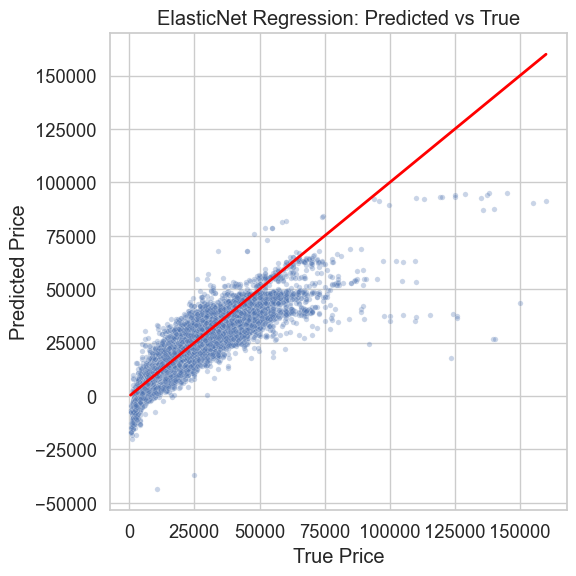

In [ ]:
plot_pred_vs_true(en_final, "ElasticNet Regression")

### 4.2. Residuals vs Predicted (heteroscedasticity check)

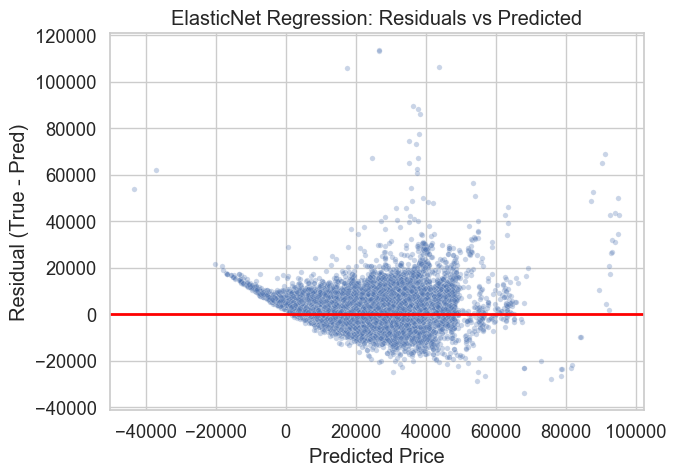

In [ ]:
plot_residuals(en_final, "ElasticNet Regression")

### 4.3. Residual distribution

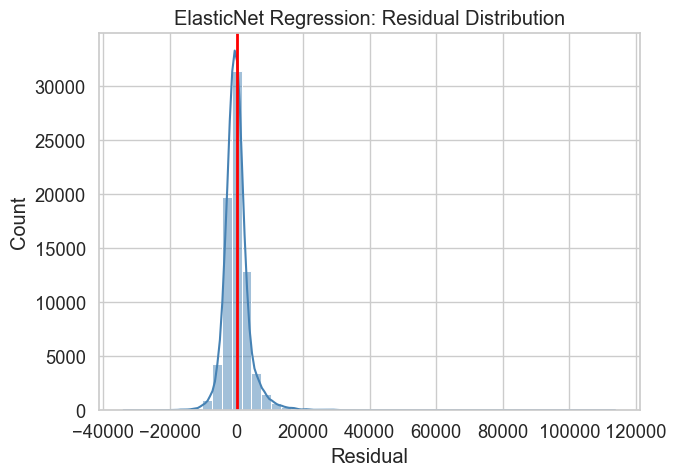

In [ ]:
plot_residual_distribution(en_final, "ElasticNet Regression")

### 4.4. Permutation Importance

/var/folders/ts/9fy52qg56jz05nxpdkmswkzw0000gr/T/ipykernel_71204/2081930191.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="magma")


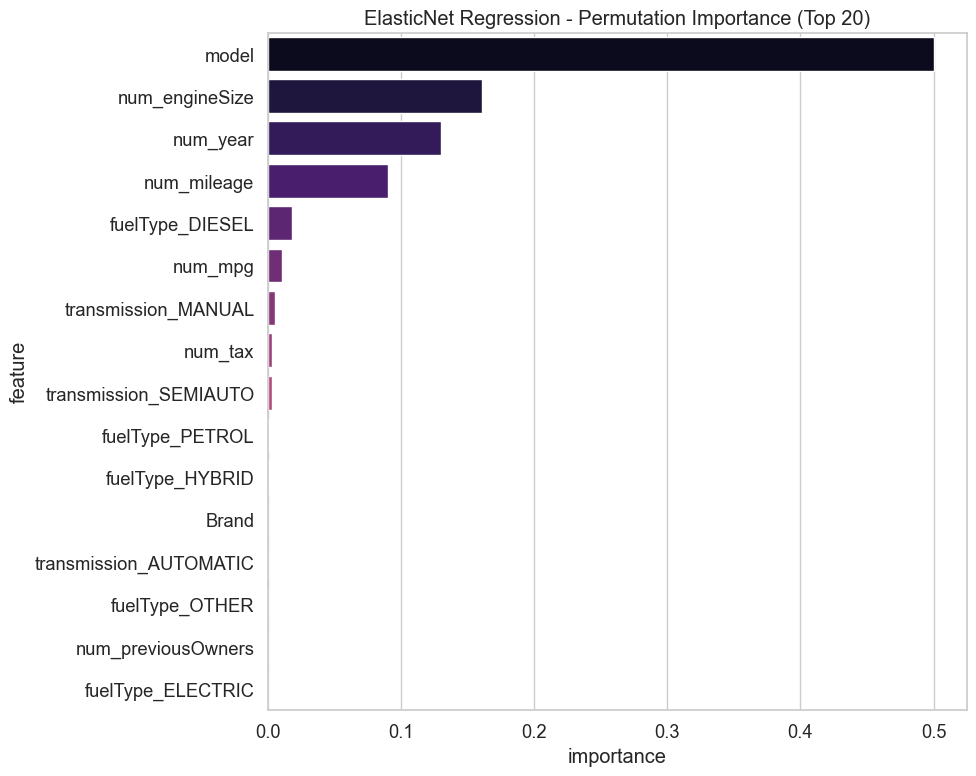

In [ ]:
plot_permutation_importance(en_final, "ElasticNet Regression")

### 4.5. SHAP


SHAP for ElasticNet Regression (sample size = 2000)


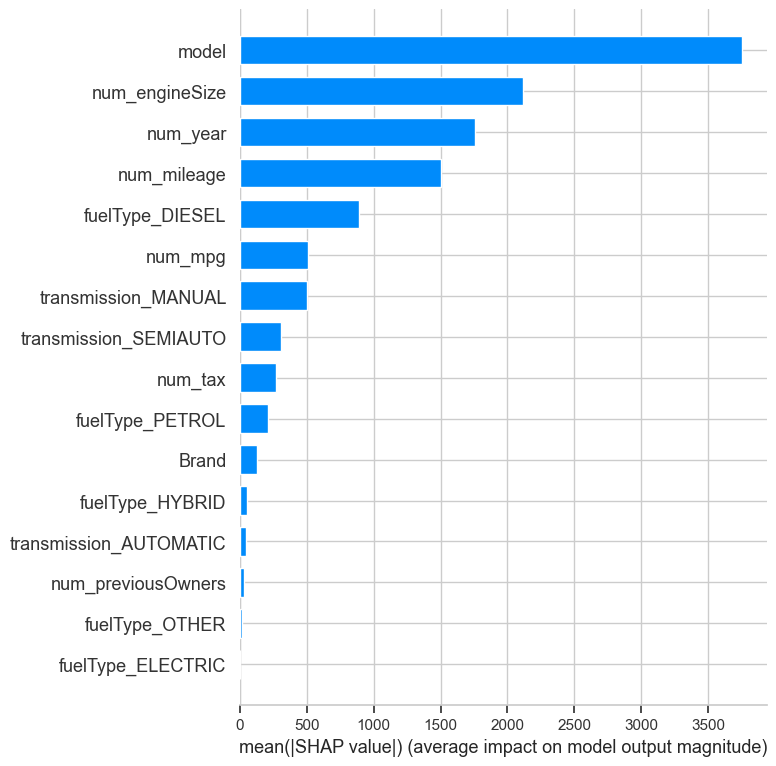

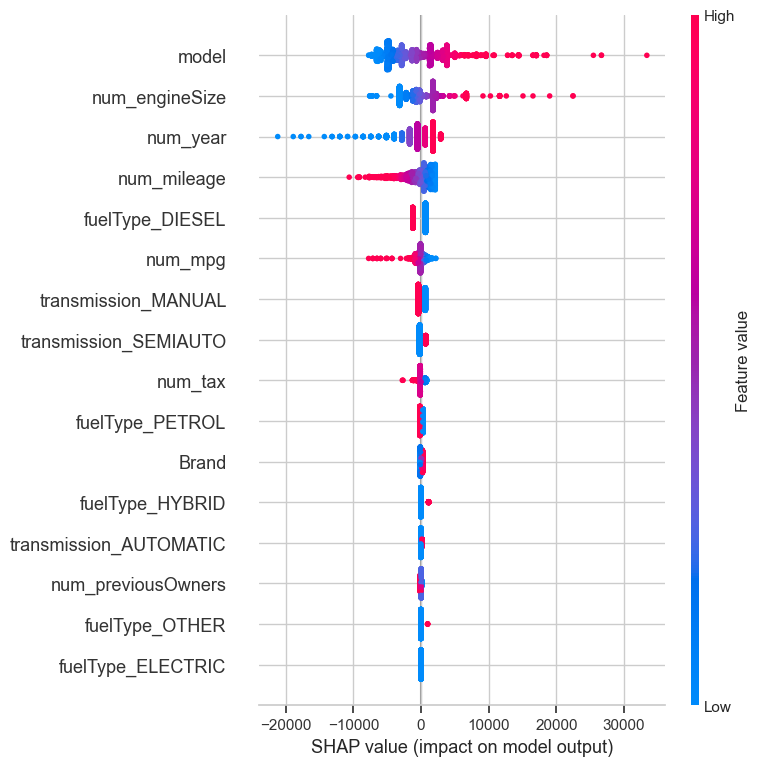

In [ ]:
X_shap = X_full_final.copy()
X_shap = X_shap.astype(float)  # converts bool to 0/1 and ensures consistent dtype

apply_shap(en_final, X_shap, "ElasticNet Regression")

--------

## Coefficient magnitude comparison 

<Figure size 1200x700 with 0 Axes>

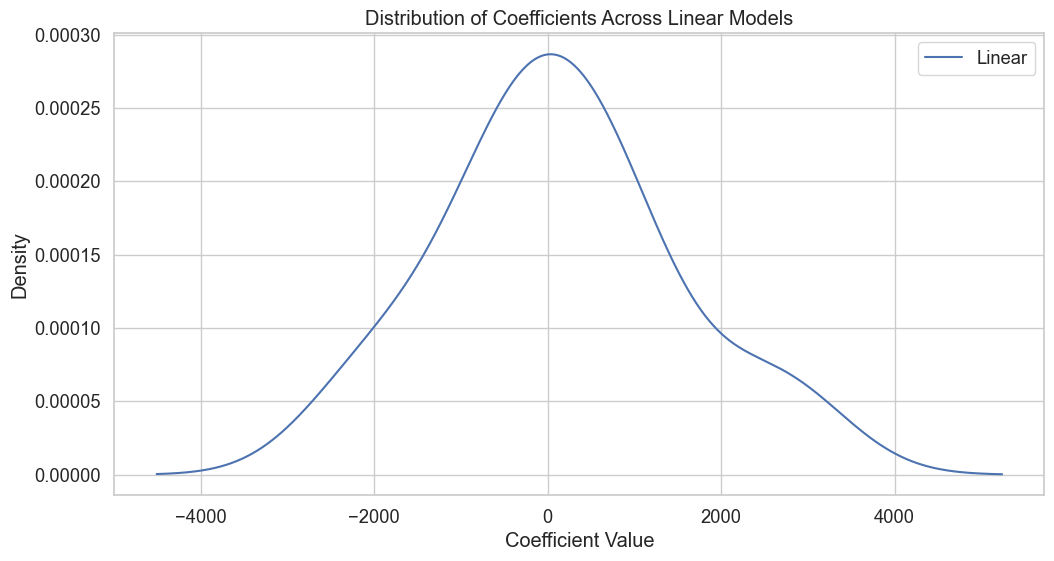

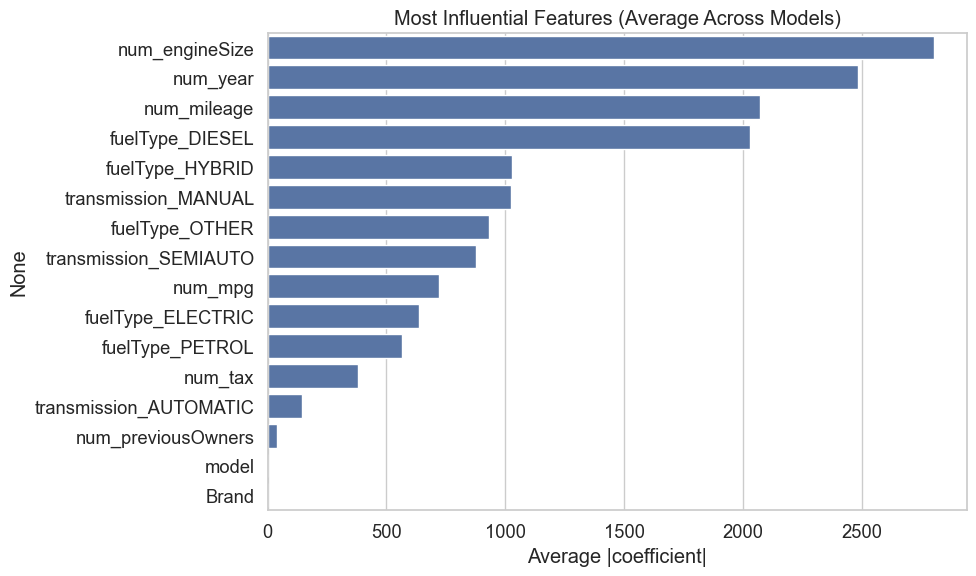

In [ ]:
models = [linreg_final, ridge_final, lasso_final, en_final]
model_names = ["Linear", "Ridge", "Lasso", "ElasticNet"] # run this after running Ridge, Lasso and ElasticNet notebooks for comparison!

plot_coefficients(models, model_names)